# What would it take for the ATB nuclear cost projections to happen?

**What this notebook does.** NREL's ATB 2024 publishes three overnight-cost (OCC) trajectories per
nuclear technology — *conservative*, *moderate*, and *advanced* — sourced from Abou-Jaoude et al.
(INL), who pair each cost trajectory with a deployment projection (12 / 34 / 200 GW of new builds by
2050). This notebook **inverts the paper's Monte-Carlo OCC engine** to answer research question 2 of
the nuclear-learning paper: *what learning-parameter conditions are needed for the ATB cost
trajectories to happen?* Two analyses:

- **Part 1 — trajectory match at the paired deployment.** For each technology × ATB scenario, with
  deployment fixed at the matching Abou-Jaoude projection, find *every* combination of learning
  rate, spillover, vendor count, experience-base convention, international deployment, and CES
  structure whose OCC path reproduces the ATB trajectory — the *feasible set*, not a point estimate.
- **Part 2 — the 2050 endpoint with deployment free.** Because the engine's OCC in any year depends
  on deployment only through the *cumulative* stock in that year (shown and QA-verified in A6),
  "deployment" collapses to a single scalar — GW built 2030→2050 — and we can chart the *required
  deployment* surface that delivers each ATB 2050 cost.

**Scenario names.** ATB/Abou-Jaoude say *advanced* where casual usage says "high" (ambition) or
"low" (cost). Cost scenarios and deployment scenarios share names and are paired by the source:

| scenario | SMR OCC 2030 → 2050 ($/kW) | large OCC 2030 → 2050 | new deployment by 2050 |
|---|---|---|---|
| conservative | 10,000 → 6,250 | 7,750 → 6,000 | 12 GW |
| moderate | 8,000 → 4,000 | 5,750 → 3,750 | 34 GW |
| advanced | 5,500 → 2,000 | 5,250 → 2,250 | 200 GW |

**Basis.** OCC in $/kW, 2022 USD, IDC-exclusive — the ATB basis, identical to the engine's, so no
financing adjustment appears anywhere in this notebook (construction durations and the ReEDS
financing chain are deliberately out of scope; see the companion `mc_cost_trajectories.ipynb` S6–S7).

**Relationship to the companion notebooks.** The OCC engine cells are verbatim ports from
`mc_cost_trajectories.ipynb` (S1/S3/S5), and QA-0 asserts the port reproduces the companion's
per-draw export (`exports/mc_perdraw.npz`) bit-for-bit — the house convention for engine reuse
(`smr100_case_export.ipynb` set the precedent). Nothing here re-runs the Monte Carlo and nothing
here writes ReEDS inputs; every output lands in `exports/atb/` and `figures/atb_*.png`.

In [1]:
# A1 - Setup: paths, seeding, and the house figure style
import json
import sys
import zlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, BoundaryNorm
from scipy import stats

# --- Paths: anchored to this notebook's folder, never the launch directory ---
NB_DIR = Path.cwd() if Path.cwd().name == "mc" else Path("z-ethan/mc").resolve()
assert (NB_DIR / "pris_loader.py").exists(), f"notebook folder not found from {Path.cwd()}"
REPO_ROOT = NB_DIR.parent.parent               # the ReEDS-nuclear-learning fork
EXPORTS = NB_DIR / "exports"
ATB_OUT = EXPORTS / "atb"                      # everything this notebook writes goes here...
FIGURES = NB_DIR / "figures"                   # ...and here, prefixed atb_
for d in (EXPORTS, ATB_OUT, FIGURES):
    d.mkdir(exist_ok=True)

if str(NB_DIR) not in sys.path:                # make `import pris_loader` work from any launch dir
    sys.path.insert(0, str(NB_DIR))

# --- Reproducibility: one master seed, independent named streams (house convention).
# This notebook is deterministic except for the QA sample worlds, which use "atb/..." streams.
MASTER_SEED = 20260715

def rng_stream(name):
    """An independent, reproducible random generator tied to a label."""
    return np.random.default_rng(np.random.SeedSequence((MASTER_SEED, zlib.crc32(name.encode()))))

# --- House style: z-ethan/plotstyle.py is the single formatting authority ---
sys.path.insert(0, str(NB_DIR.parent))
import plotstyle as ps
ps.apply()

# Local aliases keep this notebook's historical token names; the hexes are plotstyle's.
C_LARGE, C_SMR = ps.COL["large"], ps.COL["smr"]
INK, INK2, MUTED = ps.INK, ps.MUTED, ps.FAINT
GRID, BASE, SURFACE, NEUTRAL = ps.GRID_C, ps.EDGE_C, ps.SURFACE, ps.NEUTRAL
C_TINY, C_FULL = ps.C_TINY, ps.C_FULL          # tiny-base / full-stock strata (house)
TECH_COLOR = dict(ps.COL)
TECH_LABEL = dict(ps.TECH_LABEL)

# ATB scenarios are ORDERED (conservative -> moderate -> advanced), so they are encoded as
# monotone-lightness steps of each technology's hue (sequential rule: one hue, light -> dark),
# always accompanied by direct labels or a legend - identity never rides on color alone.
# Documented exception to plotstyle's one-concept-one-hue rule: ordinal within-tech shades
# DERIVED from ps.COL's hues (plus a neutral gray ramp for tech-agnostic deployment), not
# new identities.
SCEN_ORDER = ["conservative", "moderate", "advanced"]
SCEN_COLOR = {
    "large": {"conservative": "#86b6ef", "moderate": "#3987e5", "advanced": "#184f95"},
    "smr":   {"conservative": "#f2a284", "moderate": "#eb6834", "advanced": "#a33d15"},
}
SCEN_GRAY = {"conservative": "#a8a6a0", "moderate": "#6e6c67", "advanced": "#0b0b0b"}

# Sequential single-hue ramp for magnitude heatmaps (light -> dark blue on the light surface).
# Documented exception: ps.CMAP_SEQ (cividis) would recolor the feasible-region /
# required-deployment map semantics established here (light = low misfit / small program,
# dark = infeasible / huge program), so the local blues ramp stays.
CMAP_SEQ = LinearSegmentedColormap.from_list(
    "atb_blues", ["#f0efec", "#c9dcf7", "#86b6ef", "#3987e5", "#184f95", "#0c2a52"])

print(f"notebook dir : {NB_DIR}")
print(f"repo root    : {REPO_ROOT}")
print(f"outputs      : {ATB_OUT.relative_to(NB_DIR)}/ and figures/atb_*.png")

notebook dir : C:\Users\ethan\code\research\ReEDS-nuclear-learning\z-ethan\mc
repo root    : C:\Users\ethan\code\research\ReEDS-nuclear-learning
outputs      : exports\atb/ and figures/atb_*.png


## A2 — The OCC engine, ported verbatim

The next three cells are **verbatim ports** from `mc_cost_trajectories.ipynb` (S1 model-frame
constants, S3 historical/international experience, S5 engine), trimmed only of what an OCC-only
analysis never touches (schedules beyond the QA-0 check, durations, financing, the Monte-Carlo
draw). Two additions are new here and belong to this notebook:

- `make_worlds(...)` — builds *designed* worlds on a parameter grid instead of drawing them
  (adapted from `smr100_case_export.ipynb`'s `make_world`, with the learning-rate and anchor-cost
  dials replaced by direct values, since each technology is fit separately);
- **QA-0** — evaluates the ported engine on the companion's own drawn worlds
  (`exports/mc_perdraw.npz`) and requires the stored OCC trajectories back, for all six schedules
  and both technologies. If that cell passes, everything downstream runs on *the* engine, not a
  paraphrase of it.

The parameter space being searched (S4 of the companion is the authoritative reference card):

| dial | range here | drawn range in the MC |
|---|---|---|
| learning rate LR (per tech) | 0.005–0.30, step 0.005 | large U(0.03, 0.12); SMR U(0.03, 0.16) |
| anchor cost BOAK | **pinned by the ATB scenario** (OCC(2030) ≡ BOAK) | large U(5250, 7750); SMR U(5500, 10000) |
| spillover scale s | 0–1, 21 steps | U(0, 1) |
| international position u | 0–1, 21 steps | U(0, 1) |
| vendor count m | {4…8} | discrete uniform |
| experience base | {tiny-base, full-stock} | 50/50 |
| CES ρ | {−1, 0, 1} | uniform choice |
| cross-tech spillover x_ls, x_sl | pinned at 0.15 (inert: no other-tech program) | U(0, 0.30) each direction |

International experience follows the companion's engine (S5 Step 5): θ·s-weighted foreign units
enter the **cross-firm** channel, unsplit across technologies — the Kim & Verdolini flows are
normalized to the domestic inter-firm citation baseline, so ω prices the firm wall and θ the
national border. The drawn cross-tech x_ls/x_sl scale only the other technology's **domestic
program**, which never appears in this notebook's single-technology fits — the pinned 0.15 is
inert here and kept only for engine column-layout parity. The ρ grid is the symmetric {−1, 0, 1}.

The LR grid deliberately extends **beyond** the MC's sampled support (12% / 16% caps): if an ATB
trajectory is only reachable out there, that is a finding to report, not to hide. Every figure
shades the sampled support so inside/outside is visible at a glance.

In [2]:
# Model-frame constants - verbatim from mc_cost_trajectories.ipynb S1 (analysis switches and
# draw-count settings dropped: nothing is drawn here).
YEARS = np.arange(2024, 2051)              # annual grid, 2024-2050
T = len(YEARS)
def yi(y):
    """Index of calendar year y in the YEARS grid."""
    return int(np.where(YEARS == y)[0][0])

ANCHOR = 2030          # the anchor year: costs are pinned to known 2030 estimates (S5)
N_BOAK_UNITS = 2.0     # per-vendor experience at the anchor ("BOAK = 2OAK")
OMEGA = 1.0 / 3.0      # cross-firm learning fraction (Irwin & Klenow 1994)

# Symmetric around 0 since 2026-08-06 (companion S1): the old {-2, -1, 0, 1} grid put half
# its mass on complements, which gate the international channel to ~zero.
CES_RHO_GRID = np.array([-1.0, 0.0, 1.0])

X_SPILL_MAX = 0.30   # cross-tech spillover cap (the MC draws U(0, X_SPILL_MAX) per direction);
                     # this notebook pins x_ls = x_sl = 0.15 - inert here, since no fit ever
                     # passes an other-tech program (n_oth) to the engine

# Per-technology assumptions: unit size, learning-rate range, 2030 anchor-cost range
# (2022 USD per kW; Abou-Jaoude Table A-1 / NREL ATB 2024)
TECH = {
    "large": {"unit_gw": 1.000, "lr_lo": 0.03, "lr_hi": 0.12,
              "boak_lo": 5250.0, "boak_hi": 7750.0},
    "smr":   {"unit_gw": 0.300, "lr_lo": 0.03, "lr_hi": 0.16,
              "boak_lo": 5500.0, "boak_hi": 10000.0},
}
UNIT_FOREIGN_GW = 1.0  # foreign new builds are treated as 1-GW large reactors

U_GRID = np.linspace(0.0, 1.0, 21)   # grid for the international-deployment position u (S3)

print(f"model frame: {YEARS[0]}-{YEARS[-1]} annual (T={T}), anchor {ANCHOR}, "
      f"BOAK=2OAK per vendor, omega={OMEGA:.3f}")

model frame: 2024-2050 annual (T=27), anchor 2030, BOAK=2OAK per vendor, omega=0.333


In [3]:
# Historical + international experience - verbatim from mc_cost_trajectories.ipynb S3.
# Non-US regional milestones (GW): 2024, 2030 Low/High, 2040 Low/High, 2050 Low/High
# (IAEA RDS-1 2025 projections + WNA/CNA).
REGION_MILESTONES = {
    "CA":  (12.7, 12.7, 12.7, 18.8, 23.0, 30.0, 63.7),
    "SAM": (5.1, 5, 5, 8, 11, 8, 20),
    "WEU": (95.4, 86, 92, 81, 114, 68, 136),
    "EEU": (53.6, 57, 57, 58, 82, 68, 103),
    "AF":  (1.9, 4, 5, 7, 12, 12, 30),
    "WA":  (5.8, 11, 11, 12, 20, 15, 35),
    "SA":  (11.1, 18, 22, 25, 43, 45, 85),
    "CEA": (94.5, 136, 144, 215, 264, 242, 328),
    "SEA": (0, 0, 0, 3, 7, 4, 18),
    "OC":  (0, 0, 0, 0, 0, 0, 2),
}
# Kim & Verdolini (2023)-derived knowledge-spillover ceilings (US as recipient)
THETA_KV = {"CA": 0.28, "SAM": 0.14, "WEU": 0.17794117647, "EEU": 0.1325, "AF": 0.16688725490,
            "WA": 0.13375, "SA": 0.185, "CEA": 0.135, "SEA": 0.16583333, "OC": 0.18}
REGIONS = list(THETA_KV.keys())

import pris_loader as pl

US_GW_2024 = 97.0
PRIS_UNITS = pl.load_units(str(NB_DIR / "rds2_2025_units.csv"))
_milestones_2024 = {r: REGION_MILESTONES[r][0] for r in REGIONS} | {"US": US_GW_2024}
_issues = pl.validate_units(PRIS_UNITS[PRIS_UNITS["status"] == "operational"], _milestones_2024)
assert not _issues, _issues   # the data file must reproduce the IAEA's own totals

FLEET = PRIS_UNITS[PRIS_UNITS["status"] == "operational"]
UC_UNITS = PRIS_UNITS[PRIS_UNITS["status"] == "under construction"]

def retirement_flow_gw(key, life_yr):
    """GW retiring per model year, from each unit's real grid-connection date + a lifetime rule."""
    return pl.retirement_schedule(FLEET, pd.Index(YEARS), lifetime_years=life_yr,
                                  region=key).to_numpy()

PIPE_END = 2030   # pipeline's real visibility horizon; structurally zero after 2030 (mc S3)
PIPELINE_GW = {r: pl.committed_pipeline(UC_UNITS[UC_UNITS["region"] == r],
                                        pd.Index(np.arange(2025, PIPE_END + 1)),
                                        lead_time_months=72).to_dict()
               for r in REGIONS}

# Under-construction units are excluded: 5 carry PLANNED grid dates (not completed experience)
_ever = PRIS_UNITS[(PRIS_UNITS["status"] != "under construction")
                   & PRIS_UNITS["grid_connection"].notna()]
HIST_UNITS = {r: int((_ever["region"] == r).sum()) for r in REGIONS + ["US"]}

US_LICENSE_LIFE = 80.0   # yr - US subsequent-license-renewal trend; ~0 US retirements before 2050
ONE_FACTOR_DELTA = 0.0   # bounded regional noise on u (0 = one global u; variance-conservative)

def net_path_gw(region, u):
    """Regional net capacity path: interpolate the 2024/2030/2040/2050 milestones, positioned
    between Low and High by the global deployment draw u."""
    c = REGION_MILESTONES[region]
    vals = [c[0], c[1] + u*(c[2]-c[1]), c[3] + u*(c[4]-c[3]), c[5] + u*(c[6]-c[5])]
    return np.interp(YEARS, [2024, 2030, 2040, 2050], vals)

def gross_additions_gw(region, u):
    """The retirement identity: builds = max(0, capacity change + retirements); the committed
    pipeline REPLACES the interpolated path through PIPE_END = 2030 (real units; structurally
    zero after 2030, so it only shapes the pre-anchor record - see mc_cost_trajectories S3)."""
    dnet = np.diff(net_path_gw(region, u), prepend=net_path_gw(region, u)[0])
    ret = retirement_flow_gw(region, 65.0 + 5.0*u)   # IAEA-calibrated lives, 65+5u (mc S3; 2026-08-05)
    g = np.clip(dnet + ret, 0.0, None)
    pipe_mask = YEARS <= PIPE_END
    g[pipe_mask] = [PIPELINE_GW[region].get(int(y), 0.0) for y in YEARS[pipe_mask]]
    return g

def post_anchor_cum(flow):
    """Cumulative builds counted from the 2030 anchor, END-of-year basis. The one-year
    completion lag - a year's builds price only LATER years - is applied at the pricing
    boundary (lag1 in the engine cell), companion-identical."""
    x = flow.copy()
    x[YEARS <= ANCHOR] = 0.0
    return np.cumsum(x)

# Foreign stocks on the u grid (mc S3): unsplit, 1-GW basis - the engine's cross-firm
# channel does not distinguish designs (mc S5 Step 5). The IAEA SMR-share split of the
# foreign fleet lives in the main notebook's S14 own-routing sensitivity, not in any engine.
# REGION_STOCK[r][gi] = cumulative post-anchor units at u = U_GRID[gi]
REGION_STOCK = {}
for r in REGIONS:
    m_a = np.empty((len(U_GRID), T))
    for gi, u in enumerate(U_GRID):
        m_a[gi] = post_anchor_cum(gross_additions_gw(r, u)) / UNIT_FOREIGN_GW
    REGION_STOCK[r] = m_a

US_RET = retirement_flow_gw("US", US_LICENSE_LIFE)

# The six paper schedules, read from the exported single source of truth - needed ONLY by QA-0
# (to reproduce the companion's trajectories); the analysis itself uses the Abou-Jaoude
# deployments built in A3.
OFFSET_GW = 3.0
_sched = pd.read_csv(REPO_ROOT / "inputs" / "nuclear_learning" / "US_SCHEDULES.csv",
                     comment="#").set_index("year")
assert list(_sched.index) == list(YEARS)
SCEN_TOKENS = list(_sched.columns)
USN_NEW = {}     # USN_NEW[tech][token] -> (T,) cumulative post-anchor new units
for tech in TECH:
    USN_NEW[tech] = {}
    for tok in SCEN_TOKENS:
        cap = _sched[tok].to_numpy(float) - OFFSET_GW
        dnet = np.diff(cap, prepend=cap[0])
        USN_NEW[tech][tok] = post_anchor_cum(np.clip(dnet + US_RET, 0.0, None)) / TECH[tech]["unit_gw"]

print(f"PRIS fleet loaded: {len(FLEET)} operational, {len(UC_UNITS)} under construction; "
      f"schedules for QA-0: {SCEN_TOKENS}")

PRIS fleet loaded: 417 operational, 62 under construction; schedules for QA-0: ['eia_aeo_high', 'abou_jaoude', 'iaea_high', 'mckinsey', 'cop28', 'eo2025']


In [4]:
# The OCC engine - verbatim from mc_cost_trajectories.ipynb S5 (draw_world not ported: this
# notebook evaluates designed worlds, it draws none), plus the two additions described above.
H_ALL_W = sum(THETA_KV[r]*HIST_UNITS[r] for r in REGIONS)   # theta-weighted historical foreign stock
OTHER_TECH = {"large": "smr", "smr": "large"}
X_IN_COL = {"large": "x_sl", "smr": "x_ls"}     # incoming cross-tech fraction, per receiving tech

def lag1(a):
    """One-year completion lag along the time axis: the stock ENTERING year t is the builds
    completed through t-1. Cumulative arrays stay end-of-year for accounting; the lag is
    applied here, at the pricing boundary - without it the first post-anchor cohort would
    price on its own not-yet-built units (below BOAK). Companion-identical (mc S5)."""
    a = np.asarray(a, float)
    out = np.zeros_like(a)
    out[..., 1:] = a[..., :-1]
    return out

def experience_channels(world, tech, n_us, n_oth=None):
    """The two experience stocks O_d(t) (own) and A_d(t) (cross-firm), each (n_draws, T).

    n_us:  the schedule's cumulative post-anchor US builds of THIS technology, shape (T,).
    n_oth: the OTHER technology's cumulative post-anchor US builds, (T,) or None. The drawn
           incoming cross-tech fraction x scales it into the cross-firm channel; this
           notebook's single-technology fits never pass it, so x stays inert here.

    International experience enters the CROSS-FIRM channel at weight s*theta, unsplit
    across technologies (mc S5 Step 5): the Kim & Verdolini flows are normalized to the
    domestic INTER-FIRM citation baseline (their eq. (5); self-citations excluded), so
    theta prices the extra national border ON TOP OF the firm wall - omega once for the
    firm wall, theta once for the border.
    """
    n = len(world)
    u_r = np.repeat(world["u"].values[:, None], len(REGIONS), axis=1)
    if ONE_FACTOR_DELTA > 0:   # optional bounded regional noise on u (off by default)
        u_r = np.clip(u_r + rng_stream("one_factor_noise").uniform(
            -ONE_FACTOR_DELTA, ONE_FACTOR_DELTA, (n, len(REGIONS))), 0, 1)
    gi = np.clip(np.rint(u_r * (len(U_GRID)-1)).astype(int), 0, len(U_GRID)-1)
    S_kv = np.zeros((n, T))
    for j, r in enumerate(REGIONS):
        S_kv += THETA_KV[r] * REGION_STOCK[r][gi[:, j], :]
    S_kv = lag1(S_kv)                                    # stock entering year t (built thru t-1)
    N_us = lag1(np.broadcast_to(np.asarray(n_us, float), (n, T)))
    conv = world["conv_full"].values[:, None].astype(float)
    m = world["n_vendors"].values[:, None].astype(float)
    s = world["s"].values[:, None]
    # US historical fleet counts toward LARGE only (D8'): the SMR learning-rate range is
    # empirically derived and already embeds any benefit from prior LWR builds, so crediting
    # the ~140-unit US stock to the SMR base would double-count it. The theta-weighted
    # FOREIGN stock (historical and projected) is not-own-design experience for both
    # technologies alike and enters the cross-firm channel unsplit.
    hist_us = HIST_UNITS["US"] if tech == "large" else 0.0
    own0 = N_BOAK_UNITS + conv*hist_us/m                     # per-vendor domestic base (D8/D8')
    own = own0 + N_us/m                                      # own-design units, learn at LR
    oth = (m-1.0)*own0 + N_us*(m-1.0)/m \
          + s*(conv*H_ALL_W + S_kv)                          # others + international, at OMEGA*LR
    if n_oth is not None:                                    # cross-tech: the other technology's
        x = world[X_IN_COL[tech]].values[:, None]            # incoming cross-tech fraction
        oth = oth + x*lag1(np.broadcast_to(np.asarray(n_oth, float), (n, T)))  # US program (Step 5')
    return own, oth

def occ_paths(world, tech, n_us, n_oth=None):
    """Reference engine (D9, sigma = 1). Kept untouched as the regression benchmark for the
    CES engine below - QA-1 asserts occ_paths_ces(rho -> 0) reproduces it exactly. n_oth
    passes through to experience_channels."""
    own, oth = experience_channels(world, tech, n_us, n_oth=n_oth)
    lr = world[f"lr_{tech}"].values[:, None]
    mult = ((own/own[:, [yi(ANCHOR)]])**np.log2(1.0 - lr)
            * (oth/oth[:, [yi(ANCHOR)]])**np.log2(1.0 - OMEGA*lr))
    return world[f"boak_{tech}"].values[:, None] * mult

CES_EPS = 1e-8   # |ces_rho| below this takes the closed-form geometric-mean branch

def occ_paths_ces(world, tech, n_us, n_oth=None, ces_rho=None):
    """Production engine (D11/D12): CES power-mean aggregation of the two channels,
    E = (w O^rho + (1-w) A^rho)^(1/rho), OCC = BOAK (E(t)/E(2030))^(-b), with (w, b)
    derived per-draw from (LR, omega) so the rho -> 0 member reproduces occ_paths EXACTLY.
    n_oth passes through to experience_channels."""
    own, oth = experience_channels(world, tech, n_us, n_oth=n_oth)
    assert own.min() >= N_BOAK_UNITS and oth.min() >= N_BOAK_UNITS, "stock below anchor base; log unsafe"
    lr = world[f"lr_{tech}"].values[:, None]
    b1, b2 = np.log2(1.0 - lr), np.log2(1.0 - OMEGA*lr)     # channel exponents, both < 0
    b, w = -(b1 + b2), b1/(b1 + b2)                         # b > 0, w in (0,1)  (D12)
    rho = world["ces_rho"].values if ces_rho is None else np.full(len(world), float(ces_rho))
    rho = rho[:, None]
    geo = np.abs(rho) < CES_EPS
    lnO, lnA = np.log(own), np.log(oth)
    with np.errstate(over="raise"):
        lnE = np.where(geo, w*lnO + (1.0-w)*lnA,
                       lnO + np.log1p((1.0-w)*np.expm1(np.where(geo, 0.0, rho)*(lnA - lnO)))
                           / np.where(geo, 1.0, rho))
    return world[f"boak_{tech}"].values[:, None] * np.exp(-b*(lnE - lnE[:, [yi(ANCHOR)]]))

def eq12_gen(N, LR, m):
    """Abou-Jaoude eq. (12) generalized to m vendors (companion QA3): the closed form the
    engine collapses to at s = 0, tiny base, rho = 0."""
    return (1-LR)**np.log2(N/m) * (1-OMEGA*LR)**np.log2((m-1)*N/m)

def make_worlds(lr, boak, u, s, m, conv, rho):
    """Designed-world frame for the engine: every input pinned, no draws (adapted from
    smr100_case_export.ipynb's make_world; the lr/boak dials are direct values here, applied
    to BOTH techs' columns - each fit evaluates a single technology, so the twin columns are
    just along for the engine's column layout)."""
    arrs = np.broadcast_arrays(*[np.asarray(a, float) for a in (lr, boak, u, s, m, conv, rho)])
    w = pd.DataFrame(index=range(arrs[0].size))
    for tech in TECH:
        w[f"lr_{tech}"] = arrs[0].ravel()
        w[f"boak_{tech}"] = arrs[1].ravel()
    for k, a in zip(("u", "s", "n_vendors", "conv_full", "ces_rho"),
                    (arrs[2], arrs[3], arrs[4], arrs[5], arrs[6])):
        w[k] = a.ravel()
    w["x_ls"] = 0.15   # cross-tech spillover fractions, pinned at the drawn range's midpoint -
    w["x_sl"] = 0.15   # inert here (no other-tech program is passed; companion S5 Step 5')
    return w

print(f"engine ready: H_ALL_W = {H_ALL_W:.1f} theta-weighted historical foreign units; "
      f"US historical fleet = {HIST_UNITS['US']} units (large only, full-stock convention)")

engine ready: H_ALL_W = 83.5 theta-weighted historical foreign units; US historical fleet = 135 units (large only, full-stock convention)


In [5]:
# QA-0 - engine-port parity: evaluate the ported engine on the companion's OWN drawn worlds
# and require the stored OCC trajectories back, for all six schedules x both technologies.
# This is the smr100_case_export QA-0 pattern, inverted: instead of re-drawing the worlds we
# load them, so the check isolates the ENGINE port (experience stocks, CES aggregation,
# anchor convention) from the sampler. Tolerance is cross-kernel floating-point rounding only.
_npz_path = EXPORTS / "mc_perdraw.npz"
assert _npz_path.exists(), ("exports/mc_perdraw.npz not found - run mc_cost_trajectories.ipynb "
                            "(S10b) first; QA-0 is the gate that this notebook runs the real engine")
Z0 = np.load(_npz_path, allow_pickle=False)
_wcols = [str(c) for c in Z0["world_columns"]]
assert list(Z0["years"]) == list(YEARS)
for tok in SCEN_TOKENS:
    _w = pd.DataFrame(Z0[f"worlds_{tok}"], columns=_wcols)
    for tech in TECH:
        _occ = occ_paths_ces(_w, tech, USN_NEW[tech][tok])
        assert np.allclose(_occ, Z0[f"occ_{tok}_{tech}"], rtol=1e-9, atol=0.0), (tok, tech)
_n0 = Z0[f"worlds_{SCEN_TOKENS[0]}"].shape[0]
print(f"QA-0 PASSED: ported engine reproduces the companion's OCC trajectories on its own "
      f"{_n0:,} drawn worlds, all {len(SCEN_TOKENS)} schedules x both techs (rtol 1e-9)")
del Z0, _w, _occ

QA-0 PASSED: ported engine reproduces the companion's OCC trajectories on its own 10,000 drawn worlds, all 6 schedules x both techs (rtol 1e-9)


## A3 — The targets: ATB cost trajectories and Abou-Jaoude deployments

Two inputs define the inversion:

1. **Cost targets** — the six ATB 2024 files the ReEDS fork itself ships
   (`inputs/plant_characteristics/{nuclear,nuclear-smr}_ATB_2024_{scenario}.csv`), $/kW 2022 USD,
   IDC-exclusive, annual 2010–2050. The fit uses the five milestone years 2030/2035/2040/2045/2050
   (the years Abou-Jaoude's tables actually specify; the annual files interpolate between them).
   **The 2030 value is not a fit target** — the engine's anchor convention makes OCC(2030) ≡ BOAK,
   so each ATB scenario *pins* the anchor exactly and the fit is on curve shape 2035–2050 only.
2. **Deployment paths** — `z-ethan/abou-jaoude nuclear deployment projections.csv` (the paper's
   Table values: GW of new deployment at 5-year milestones). Converted to the engine's `n_us`
   (cumulative post-anchor units) by linear interpolation to the annual grid, zeroing flows at or
   before 2030 (the anchor convention — the 1 GW the moderate/advanced scenarios place *by* 2030
   is treated as part of the anchor, not as post-anchor experience), and dividing by unit size
   (1 GW large, 0.3 GW SMR). These are *new-build additions*, not net fleet capacity, so no
   retirement identity applies. Both technologies face the same GW program — the source projects
   program size, not a technology split — which is also the paper's 100%-winner convention.

The scenario pairing is the source's own: conservative costs were derived assuming conservative
deployment, and so on. Part 1 fits the matched pairs; the cross-pairing grid (F5) quantifies how
much that pairing matters.

In [6]:
# Load the ATB targets and build the Abou-Jaoude deployment inputs.
ATB_NAME = {"large": "nuclear", "smr": "nuclear-smr"}
PC_DIR = REPO_ROOT / "inputs" / "plant_characteristics"

def atb_capcost(tech, scen):
    """ATB 2024 capcost on the YEARS grid (2022$/kW, idc-exclusive)."""
    f = PC_DIR / f"{ATB_NAME[tech]}_ATB_2024_{scen}.csv"
    return pd.read_csv(f).set_index("t")["capcost"].loc[YEARS].to_numpy(float)

MILESTONES = [2030, 2035, 2040, 2045, 2050]
MYEARS = MILESTONES[1:]                       # the fit years (2030 is exact by construction)
MI = [yi(y) for y in MILESTONES]

ATB_OCC = {t: {s: atb_capcost(t, s) for s in SCEN_ORDER} for t in TECH}
TARGET = {t: {s: ATB_OCC[t][s][MI] for s in SCEN_ORDER} for t in TECH}     # at MILESTONES
BOAK_PIN = {t: {s: float(TARGET[t][s][0]) for s in SCEN_ORDER} for t in TECH}

# Consistency check (npv_winner_check QA-B): the MC's anchor ranges ARE the ATB
# advanced/conservative 2030 capcosts, so the scenario pins BOAK inside the engine's own range.
for t in TECH:
    assert (BOAK_PIN[t]["advanced"], BOAK_PIN[t]["conservative"]) == \
           (TECH[t]["boak_lo"], TECH[t]["boak_hi"]), t
    assert TECH[t]["boak_lo"] <= BOAK_PIN[t]["moderate"] <= TECH[t]["boak_hi"], t

# Abou-Jaoude deployment projections (GW of new deployment, 5-year milestones)
_aj = pd.read_csv(REPO_ROOT / "z-ethan" / "abou-jaoude nuclear deployment projections.csv")
AJ_YEARS = _aj["year"].to_numpy(float)
AJ_GW = {s: _aj[s].to_numpy(float) for s in SCEN_ORDER}
# Pin the CSV to the published tables as transcribed in the companion's QA4
_aj_qa4 = {"conservative": {2030: 0, 2035: 1, 2040: 3, 2045: 6, 2050: 12},
           "moderate":     {2030: 1, 2035: 3, 2040: 8.5, 2045: 17, 2050: 34},
           "advanced":     {2030: 1, 2035: 14, 2040: 58, 2045: 124, 2050: 200}}
for s in SCEN_ORDER:
    assert dict(zip(AJ_YEARS.astype(int), AJ_GW[s])) == _aj_qa4[s], s

# Post-anchor deployment basis for Part 2: subtract the 2030 baseline (1 GW in moderate/
# advanced) so the AJ reference deployment shares N_AJ's post-anchor unit basis
# (post_anchor_cum zeroes flows <= 2030; Part 1 already counts this way).
AJ_GW_POST = {s: float(AJ_GW[s][-1] - AJ_GW[s][0]) for s in SCEN_ORDER}

# Entering-2050 scoring basis (adjudicated 2026-08-24): the engine's one-year lag means
# the stock that PRICES 2050 is the build completed through 2049. Wherever the closed-form
# 2050 evaluator (shape_2050 / required_gw, both defined on that contract) is compared
# against the AJ program (T4/T5/T6, the F6 contour, F7's reference line, F8's marker,
# QA-3 (ii)), the paired deployment must be the through-2049 cumulative - feeding the
# by-2050 total credits 2050's own completions (advanced: ~15.2 GW/yr over 2045-2050,
# a ~7.6% overstatement). Part 1 / F9 run the AJ annual path through the full engine
# (lag applied internally) and were already on this basis. The QUOTED paired-program
# totals (12/33/199 GW by 2050) stay by-2050 wherever they describe the program itself.
AJ_GW_ENT50 = {s: float(np.interp(2049.0, AJ_YEARS, AJ_GW[s]) - AJ_GW[s][0])
               for s in SCEN_ORDER}

# n_us: cumulative post-anchor new-build units on the annual grid. New-build additions, not
# net capacity: no retirement identity. Flows at or before 2030 are zeroed (anchor convention).
N_AJ = {}
for tech in TECH:
    N_AJ[tech] = {}
    for s in SCEN_ORDER:
        cap = np.interp(YEARS, AJ_YEARS, AJ_GW[s])
        dnet = np.diff(cap, prepend=cap[0])
        N_AJ[tech][s] = post_anchor_cum(np.clip(dnet, 0.0, None)) / TECH[tech]["unit_gw"]

# T1 - the inversion targets at the milestone years
_t1 = pd.DataFrame({(t, s): TARGET[t][s] for t in TECH for s in SCEN_ORDER},
                   index=pd.Index(MILESTONES, name="year"))
_t1.columns = pd.MultiIndex.from_tuples(_t1.columns, names=["tech", "scenario"])
_t1.to_csv(ATB_OUT / "atb_targets.csv")
_dep = pd.DataFrame({s: {"GW by 2050 (post-2030)": AJ_GW_POST[s],
                         "large units by 2050": round(N_AJ['large'][s][-1]),
                         "SMR units by 2050": round(N_AJ['smr'][s][-1])}
                     for s in SCEN_ORDER}).T
print("T1 - ATB OCC targets ($/kW 2022) at the milestone years -> exports/atb/atb_targets.csv")
print(_t1.to_string())
print("\nAbou-Jaoude deployment scenarios (post-2030 new builds):")
print(_dep.to_string())

T1 - ATB OCC targets ($/kW 2022) at the milestone years -> exports/atb/atb_targets.csv
tech            large                            smr                  
scenario conservative moderate advanced conservative moderate advanced
year                                                                  
2030           7750.0   5750.0   5250.0      10000.0   8000.0   5500.0
2035           7750.0   5500.0   4000.0       9500.0   6500.0   3250.0
2040           7500.0   4750.0   3000.0       8000.0   5250.0   2500.0
2045           6750.0   4250.0   2500.0       7000.0   4500.0   2250.0
2050           6000.0   3750.0   2250.0       6250.0   4000.0   2000.0

Abou-Jaoude deployment scenarios (post-2030 new builds):
              GW by 2050 (post-2030)  large units by 2050  SMR units by 2050
conservative                    12.0                 12.0               40.0
moderate                        33.0                 33.0              110.0
advanced                       199.0                199.

**F1 — the inversion targets** (`atb_targets_overview.png`). **a, b** — the ATB 2024 OCC trajectories per technology (dots = fit milestones; scenario = lightness of the tech hue, light = conservative, dark = advanced; dotted vertical = the 2030 anchor). **c** — the paired Abou-Jaoude deployment projections, cumulative new GW, one program common to both technologies (gray lightness steps, same scenario order).

saved -> figures\atb_targets_overview.png


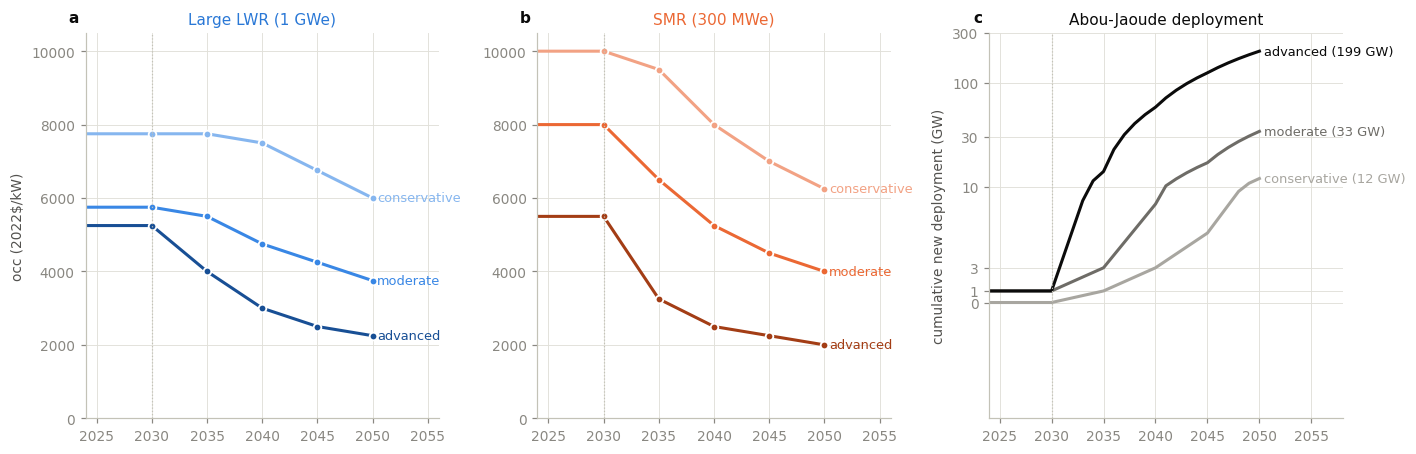

In [7]:
# F1 - what we are inverting: the ATB cost targets (left, center) and the deployment paths
# they were derived from (right). Scenario = lightness (light = conservative, dark = advanced).
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
for ax, tech in zip(axes[:2], TECH):
    for s in SCEN_ORDER:
        c = SCEN_COLOR[tech][s]
        ax.plot(YEARS[YEARS >= 2024], ATB_OCC[tech][s][YEARS >= 2024], color=c, lw=2)
        ax.plot(MILESTONES, TARGET[tech][s], "o", color=c, ms=5,
                markeredgecolor=SURFACE, markeredgewidth=1.2)
        ax.annotate(s, (2050.4, ATB_OCC[tech][s][-1]), color=c, fontsize=8.5,
                    va="center", ha="left")
    ax.axvline(ANCHOR, color=BASE, lw=0.8, ls=":")
    ax.set_xlim(2024, 2056)
    ax.set_ylim(0, 10500)
    ax.set_title(TECH_LABEL[tech], color=TECH_COLOR[tech], loc="center")
    ax.set_ylabel("occ (2022$/kW)" if tech == "large" else None)
ax = axes[2]
for s in SCEN_ORDER:
    c = SCEN_GRAY[s]
    ax.plot(YEARS, np.interp(YEARS, AJ_YEARS, AJ_GW[s]), color=c, lw=2)
    # Label the post-2030 new-build total (AJ_GW_POST) so this agrees with F7 and T4.
    ax.annotate(f"{s} ({AJ_GW_POST[s]:,.0f} GW)", (2050.4, AJ_GW[s][-1]), color=c,
                fontsize=8.5, va="center", ha="left")
ax.axvline(ANCHOR, color=BASE, lw=0.8, ls=":")
ax.set_xlim(2024, 2058)
ax.set_yscale("symlog", linthresh=10)
ax.set_yticks([0, 1, 3, 10, 30, 100, 300])
ax.set_yticklabels(["0", "1", "3", "10", "30", "100", "300"])
ax.set_title("Abou-Jaoude deployment", loc="center")
ax.set_ylabel("cumulative new deployment (GW)")
ps.letter_panels(axes)                    # heterogeneous panels (cost, cost, deployment)
fig.tight_layout()
ps.savefig(fig, FIGURES / "atb_targets_overview.png")
plt.show()

## A4 — Part 1: the exhaustive grid search

**Method.** For each technology × scenario, deployment is fixed at the matched Abou-Jaoude path
and BOAK is pinned at the ATB 2030 anchor. The engine is then evaluated on the **full cross
product** of the remaining dials — LR (60 values) × s (21) × u (21) × m (5) × experience base (2)
× CES ρ (3) — just under **0.8 million designed worlds per fit**, following the enumeration
pattern `smr100_case_export.ipynb` established for its bounding-world search.

**One evaluation per deployment, not per scenario.** BOAK enters the engine multiplicatively
(OCC = BOAK × shape), so each world's *shape* — OCC/BOAK at the milestone years — is computed once
per (technology, deployment) and reused for every cost scenario, including the 3×3 cross-pairings
in F5. The anchor identity shape(2030) ≡ 1 is asserted for every world as the shapes are built
(QA-4).

**Misfit and feasibility.** The misfit of a world is the **worst absolute deviation from the ATB
trajectory over 2035–2050** (max-abs at the four fit milestones, $/kW). A world is *feasible* when
its misfit is at most **$250/kW** — tight enough that a feasible world's path is visually on top of
the ATB curve, looser than the $500 "report rounding" tolerance the companion's QA4 uses for
reproducing Abou-Jaoude's own tables. Feasible-set sizes at $100 and $500 are reported alongside as
a robustness check.

In [8]:
# The parameter grid, and one shape table per (technology, deployment).
import time as _time

LR_GRID = np.round(np.arange(0.005, 0.3001, 0.005), 3)      # 60 values, past the MC support
S21 = np.round(np.linspace(0.0, 1.0, 21), 3)
U21 = U_GRID.copy()
M_GRID = np.array([4.0, 5.0, 6.0, 7.0, 8.0])
CONV_GRID = np.array([0.0, 1.0])
DISC_COMBOS = [(rho, conv, m) for rho in CES_RHO_GRID for conv in CONV_GRID for m in M_GRID]

_mesh = np.meshgrid(LR_GRID, S21, U21, indexing="ij")
LRv, Sv, Uv = (a.ravel() for a in _mesh)
NPTS = LRv.size                                              # 60 x 21 x 21 = 26,460
NW = len(DISC_COMBOS) * NPTS                                 # 1,058,400 worlds per fit
GRID_SHAPE = (len(CES_RHO_GRID), len(CONV_GRID), len(M_GRID),
              len(LR_GRID), len(S21), len(U21))              # reshape order of the full grid

# Flat parameter columns, aligned with every misfit/shape array below
P = {"lr": np.tile(LRv, len(DISC_COMBOS)), "s": np.tile(Sv, len(DISC_COMBOS)),
     "u": np.tile(Uv, len(DISC_COMBOS)),
     "ces_rho": np.repeat([c[0] for c in DISC_COMBOS], NPTS),
     "conv_full": np.repeat([c[1] for c in DISC_COMBOS], NPTS),
     "n_vendors": np.repeat([c[2] for c in DISC_COMBOS], NPTS)}

# SHAPES[(tech, dep_scen)][:, k] = OCC/BOAK at MILESTONES[k]; shape(2030) == 1 asserted (QA-4)
SHAPES = {}
_t0 = _time.time()
for tech in TECH:
    for dep in SCEN_ORDER:
        shp = np.empty((NW, len(MILESTONES)), dtype=np.float32)
        n_us = N_AJ[tech][dep]
        for ci, (rho, conv, m) in enumerate(DISC_COMBOS):
            w = make_worlds(LRv, 1.0, Uv, Sv, m, conv, rho)
            occ = occ_paths_ces(w, tech, n_us)
            assert np.allclose(occ[:, yi(ANCHOR)], 1.0, rtol=0, atol=1e-12)   # QA-4 anchor identity
            shp[ci*NPTS:(ci+1)*NPTS] = occ[:, MI]
        SHAPES[(tech, dep)] = shp
print(f"QA-4 PASSED en route: shape(2030) == 1 for every world "
      f"(anchor identity OCC(2030) == BOAK)")
print(f"built {len(SHAPES)} shape tables x {NW:,} worlds in {_time.time()-_t0:.0f}s "
      f"({len(TECH)*len(SCEN_ORDER)*len(DISC_COMBOS)} engine calls)")

QA-4 PASSED en route: shape(2030) == 1 for every world (anchor identity OCC(2030) == BOAK)
built 6 shape tables x 793,800 worlds in 78s (180 engine calls)


In [9]:
# The matched-pair fits: misfit per world, feasible sets, best fits.
TOL = 250.0                      # trajectory (milestone) fit tolerance ($/kW, max-abs at 2035-2050)
TOL_END = 125.0                  # endpoint feasibility tolerance ($/kW) - 08-29 (Ethan): the ATB
                                 # rounds to the nearest $250/kW, so the true value lies within one
                                 # half-step ($125) of the published number; supersedes the
                                 # one-increment $250 endpoint criterion in F8/F9/F10 + the exports
TOLS = [100.0, 250.0, 500.0]     # robustness ladder

def misfit(tech, cost_scen, dep_scen):
    """(NW,) worst absolute deviation from the ATB trajectory over the fit milestones."""
    pred = BOAK_PIN[tech][cost_scen] * SHAPES[(tech, dep_scen)][:, 1:].astype(np.float64)
    return np.abs(pred - TARGET[tech][cost_scen][1:]).max(axis=1)

def eff_rate(lr):
    """Firm-level LR -> effective industry rate per fleet doubling (companion QA5): the
    number comparable to published program-level learning rates (~1.3 x LR)."""
    return 1.0 - (1.0 - lr)*(1.0 - OMEGA*lr)

FITS = {}                        # FITS[(tech, scen)] -> dict(mis, best index)
for tech in TECH:
    for scen in SCEN_ORDER:
        mis = misfit(tech, scen, scen)
        FITS[(tech, scen)] = {"mis": mis, "best": int(np.argmin(mis))}

# T2 - best-fit worlds (plus the Abou-Jaoude precedent row for orientation)
_rows = []
for (tech, scen), f in FITS.items():
    i = f["best"]
    in_sup = TECH[tech]["lr_lo"] <= P["lr"][i] <= TECH[tech]["lr_hi"]
    _rows.append({"tech": tech, "scenario": scen, "lr": P["lr"][i],
                  "eff_industry_rate": round(eff_rate(P["lr"][i]), 4),
                  "s": P["s"][i], "u": P["u"][i], "m": int(P["n_vendors"][i]),
                  "base": "full" if P["conv_full"][i] else "tiny",
                  "ces_rho": P["ces_rho"][i], "misfit_$kW": round(float(f["mis"][i]), 1),
                  "lr_in_MC_support": in_sup})
best_fits = pd.DataFrame(_rows).set_index(["tech", "scenario"])
best_fits.to_csv(ATB_OUT / "best_fits.csv")
print("T2 - best-fit worlds per tech x scenario -> exports/atb/best_fits.csv")
print("     (Abou-Jaoude's own SMR setting for reference: LR = 9.5%, m = 4, tiny base, s = 0)")
print(best_fits.to_string())

# T3 - feasible-set shares: over the whole grid, and within the MC's sampled LR support
_rows = []
for (tech, scen), f in FITS.items():
    sup = (P["lr"] >= TECH[tech]["lr_lo"]) & (P["lr"] <= TECH[tech]["lr_hi"])
    row = {"tech": tech, "scenario": scen, "min_misfit_$kW": round(float(f["mis"].min()), 1)}
    for tol in TOLS:
        feas = f["mis"] <= tol
        row[f"share_grid_<=${tol:.0f}"] = round(float(feas.mean()), 4)
        row[f"share_support_<=${tol:.0f}"] = round(float(feas[sup].mean()), 4)
    _rows.append(row)
feas_share = pd.DataFrame(_rows).set_index(["tech", "scenario"])
feas_share.to_csv(ATB_OUT / "feasible_share.csv")
print("\nT3 - feasible shares (of the full grid / of the grid restricted to the sampled LR "
      "support) -> exports/atb/feasible_share.csv")
print(feas_share.to_string())

# Persist the complete per-world misfit vectors (float32) for downstream/audit use, plus the
# feasible sets at the primary tolerance as compressed CSVs.
np.savez_compressed(ATB_OUT / "atb_misfit_perworld.npz",
                    lr=P["lr"].astype(np.float32), s=P["s"].astype(np.float32),
                    u=P["u"].astype(np.float32), ces_rho=P["ces_rho"].astype(np.int8),
                    conv_full=P["conv_full"].astype(np.int8),
                    n_vendors=P["n_vendors"].astype(np.int8),
                    **{f"mis_{t}_{s}": FITS[(t, s)]["mis"].astype(np.float32)
                       for t in TECH for s in SCEN_ORDER})
for (tech, scen), f in FITS.items():
    idx = np.flatnonzero(f["mis"] <= TOL)
    pd.DataFrame({k: P[k][idx] for k in P} | {"misfit": np.round(f["mis"][idx], 1)}) \
        .to_csv(ATB_OUT / f"feasible_set_{tech}_{scen}.csv.gz", index=False,
                compression="gzip")
print(f"\nwrote exports/atb/atb_misfit_perworld.npz and 6 feasible_set_*.csv.gz "
      f"(tolerance ${TOL:.0f}/kW)")

T2 - best-fit worlds per tech x scenario -> exports/atb/best_fits.csv
     (Abou-Jaoude's own SMR setting for reference: LR = 9.5%, m = 4, tiny base, s = 0)
                       lr  eff_industry_rate     s     u  m  base  ces_rho  misfit_$kW  lr_in_MC_support
tech  scenario                                                                                          
large conservative  0.200             0.2533  0.05  0.00  8  tiny     -1.0       231.9             False
      moderate      0.135             0.1739  0.05  0.45  4  tiny      1.0        78.9             False
      advanced      0.130             0.1677  0.35  1.00  4  tiny      1.0        38.2             False
smr   conservative  0.175             0.2231  1.00  1.00  6  full     -1.0       208.0             False
      moderate      0.130             0.1677  0.70  1.00  5  tiny      1.0        71.9              True
      advanced      0.125             0.1615  0.85  0.80  4  tiny      1.0       213.6              True

T3


wrote exports/atb/atb_misfit_perworld.npz and 6 feasible_set_*.csv.gz (tolerance $250/kW)


## A5 — Part 1 results: what the feasible sets look like

Four views, from most concrete to most abstract:

- **F2 — the fits themselves.** One figure per technology, split tiny-base vs full-stock rows
  like F3 — the experience-base convention is the biggest single shape lever, so each stratum
  shows its own envelope and best-fit path. Every panel overlays the ATB trajectory on the
  envelope of that stratum's feasible engine paths. Where the band hugs the target, many worlds
  work; where a stratum is empty ("no feasible world"), no world with that accounting delivers
  the trajectory at that deployment. *Feasible* = within \$250/kW of the target at every fit
  milestone (`TOL`); each panel annotates its best-fit misfit and stratum count n.
- **F3 — where in (LR, s) the feasible worlds live.** Min-misfit maps over learning rate ×
  spillover scale (minimized over u, m, ρ), split tiny-base vs full-stock — the experience-base
  convention is the biggest single shape lever. The line marks the $250/kW feasibility contour;
  the shaded vertical band is the MC's sampled LR support.
- **F4 — which dials the target actually constrains.** For each dial value, the share of feasible
  worlds among grid worlds with that value. Flat profile = the ATB curve carries no information
  about that dial; peaked profile = the dial is pinned down.
- **F5 — does the cost↔deployment pairing matter?** Min achievable misfit for all nine
  cost-scenario × deployment-scenario pairings. The bold diagonal is the source's own pairing.

House caption discipline applies unchanged: every fit is **conditional on its deployment path
happening** — a feasible set says "these parameters would deliver the ATB curve *if* this much
capacity gets built," never "these parameters are likely."

stratified feasible-set envelopes rebuilt through the engine in 2s


saved -> figures\atb_fit_envelopes_large.png


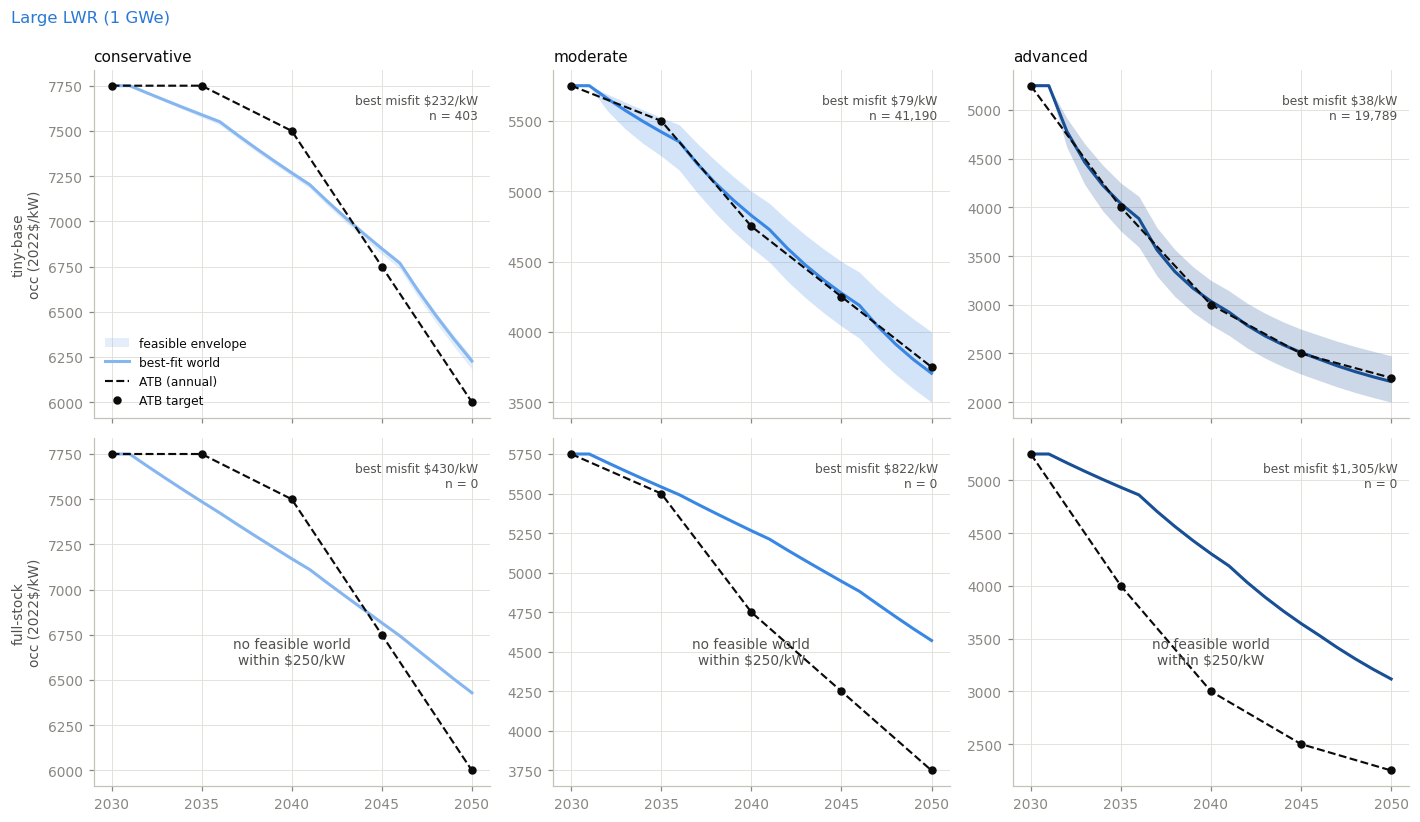

saved -> figures\atb_fit_envelopes_smr.png


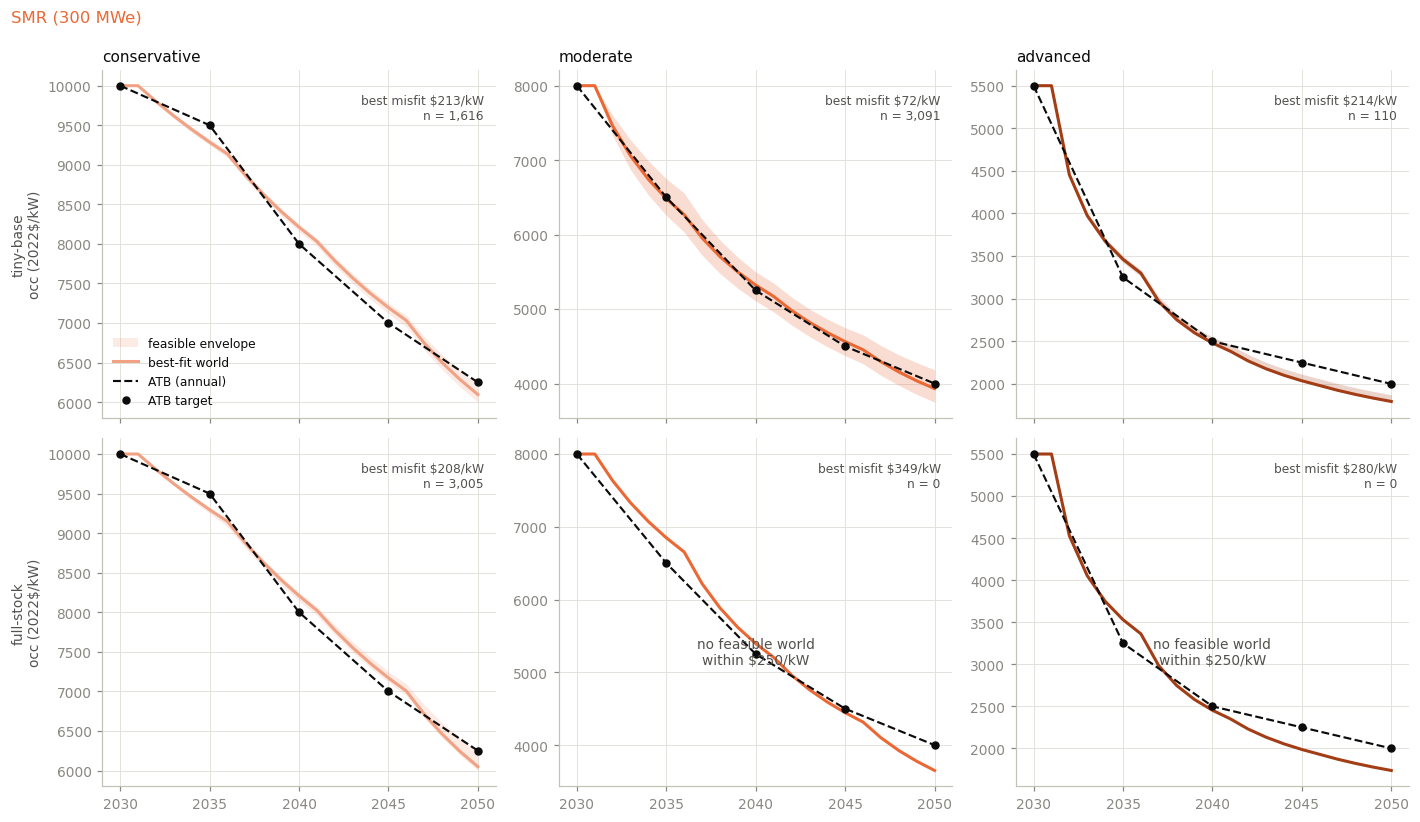

In [10]:
# F2 - ATB target vs the feasible-set envelope and best-fit path (full annual paths),
# stratified by experience-base convention (tiny-base / full-stock rows, matching F3).
# One figure per technology (atb_fit_envelopes_{tech}.png). No baked paper letters since
# 08-24: Fig 1 now composes F8 + F9 (the 2050-endpoint reframing); these path fits stay
# notebook diagnostics.
# The envelope is exact: feasible worlds are re-evaluated through the engine in blocks.
_t0 = _time.time()
ENV = {}     # ENV[(tech, scen, conv)] -> dict(lo, hi, n, best, best_mis) on the YEARS grid
for tech in TECH:
    for scen in SCEN_ORDER:
        mis = FITS[(tech, scen)]["mis"]
        n_us = N_AJ[tech][scen]
        for conv_val in (0, 1):
            lo = np.full(T, np.inf)
            hi = np.full(T, -np.inf)
            n_feas = 0
            best_i, best_mis = -1, np.inf
            for ci, (rho, conv, m) in enumerate(DISC_COMBOS):
                if conv != conv_val:
                    continue
                blk = mis[ci*NPTS:(ci+1)*NPTS]
                sel = np.flatnonzero(blk <= TOL)
                if sel.size:
                    n_feas += sel.size
                    w = make_worlds(LRv[sel], BOAK_PIN[tech][scen], Uv[sel], Sv[sel],
                                    m, conv, rho)
                    occ = occ_paths_ces(w, tech, n_us)
                    lo = np.minimum(lo, occ.min(axis=0))
                    hi = np.maximum(hi, occ.max(axis=0))
                j = int(np.argmin(blk))
                if blk[j] < best_mis:
                    best_mis, best_i = float(blk[j]), ci*NPTS + j
            wb = make_worlds(P["lr"][best_i], BOAK_PIN[tech][scen], P["u"][best_i],
                             P["s"][best_i], P["n_vendors"][best_i],
                             P["conv_full"][best_i], P["ces_rho"][best_i])
            assert int(P["conv_full"][best_i]) == conv_val
            ENV[(tech, scen, conv_val)] = {"lo": lo, "hi": hi, "n": n_feas,
                                           "best": occ_paths_ces(wb, tech, n_us)[0],
                                           "best_mis": best_mis}
print(f"stratified feasible-set envelopes rebuilt through the engine in {_time.time()-_t0:.0f}s")

post = YEARS >= ANCHOR
for tech in TECH:
    fig, axes = plt.subplots(2, 3, figsize=(13, 7.2), sharex=True)
    for r, conv_name, conv_val in [(0, "tiny-base", 0), (1, "full-stock", 1)]:
        for c, scen in enumerate(SCEN_ORDER):
            ax = axes[r, c]
            e = ENV[(tech, scen, conv_val)]
            col = SCEN_COLOR[tech][scen]
            if e["n"] > 0:
                ax.fill_between(YEARS[post], e["lo"][post], e["hi"][post], color=col,
                                alpha=0.22, lw=0, label="feasible envelope")
            else:
                ax.text(0.5, 0.35, f"no feasible world\nwithin ${TOL:.0f}/kW",
                        transform=ax.transAxes, ha="center", color=INK2, fontsize=9)
            ax.plot(YEARS[post], e["best"][post], color=col, lw=2, label="best-fit world")
            ax.plot(YEARS[post], ATB_OCC[tech][scen][post], color=INK, lw=1.4, ls="--",
                    label="ATB (annual)")
            ax.plot(MILESTONES, TARGET[tech][scen], "o", color=INK, ms=4.5,
                    label="ATB target")
            ax.text(0.97, 0.93, f"best misfit ${e['best_mis']:,.0f}/kW\nn = {e['n']:,}",
                    transform=ax.transAxes, ha="right", va="top", fontsize=8, color=INK2)
            if r == 0:
                ax.set_title(scen, fontsize=10)
            if c == 0:
                ax.set_ylabel(f"{conv_name}\nocc (2022$/kW)")
    axes[0, 0].legend(fontsize=8, loc="lower left")
    for ax in axes.ravel():
        ax.set_xticks(MILESTONES)
    fig.tight_layout()
    fig.suptitle(TECH_LABEL[tech], color=TECH_COLOR[tech], x=0.01, ha="left", y=1.03)
    ps.savefig(fig, FIGURES / f"atb_fit_envelopes_{tech}.png")
    plt.show()

_legacy = FIGURES / "atb_fit_envelopes.png"
if _legacy.exists():
    _legacy.unlink()
    print("removed legacy atb_fit_envelopes.png (superseded by the per-tech stratified files)")

saved -> figures\atb_feasible_maps_large.png


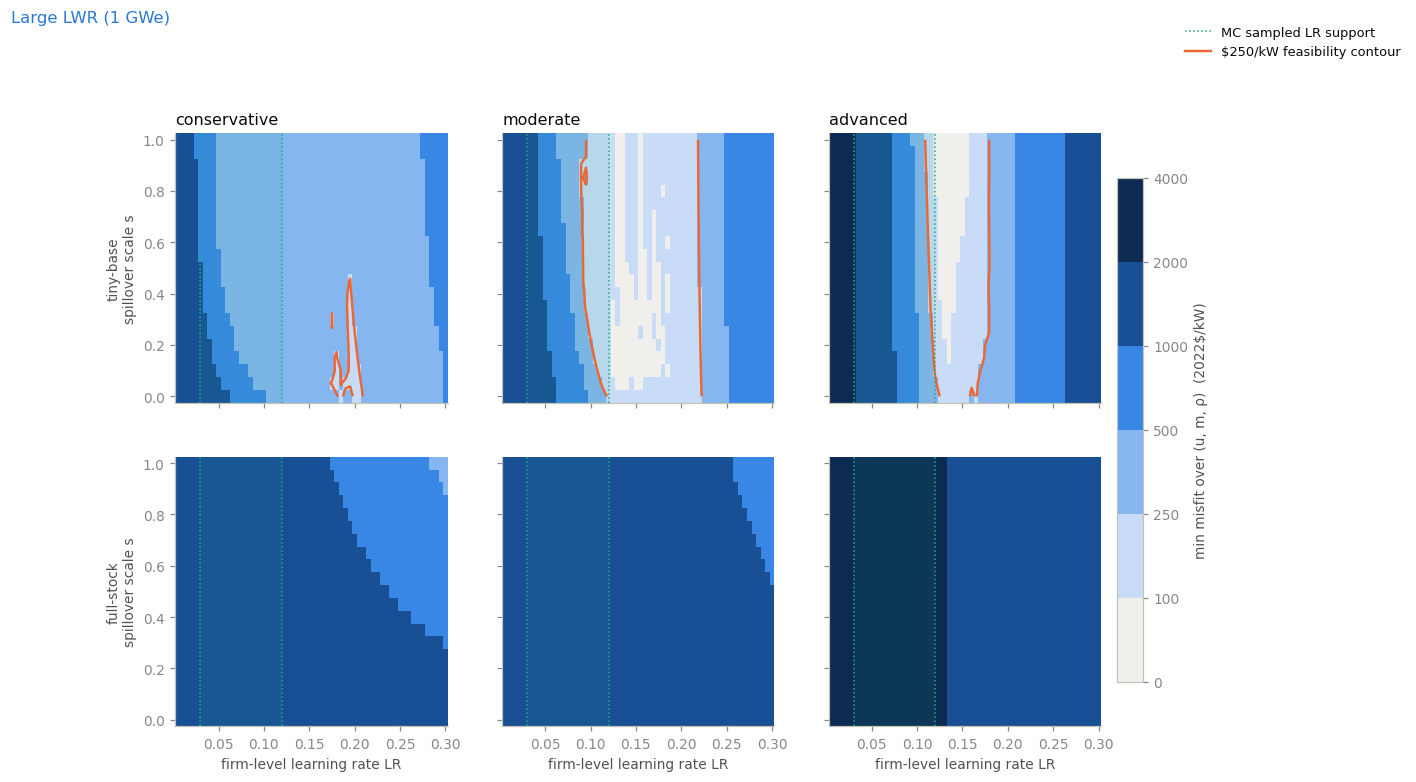

saved -> figures\atb_feasible_maps_smr.png


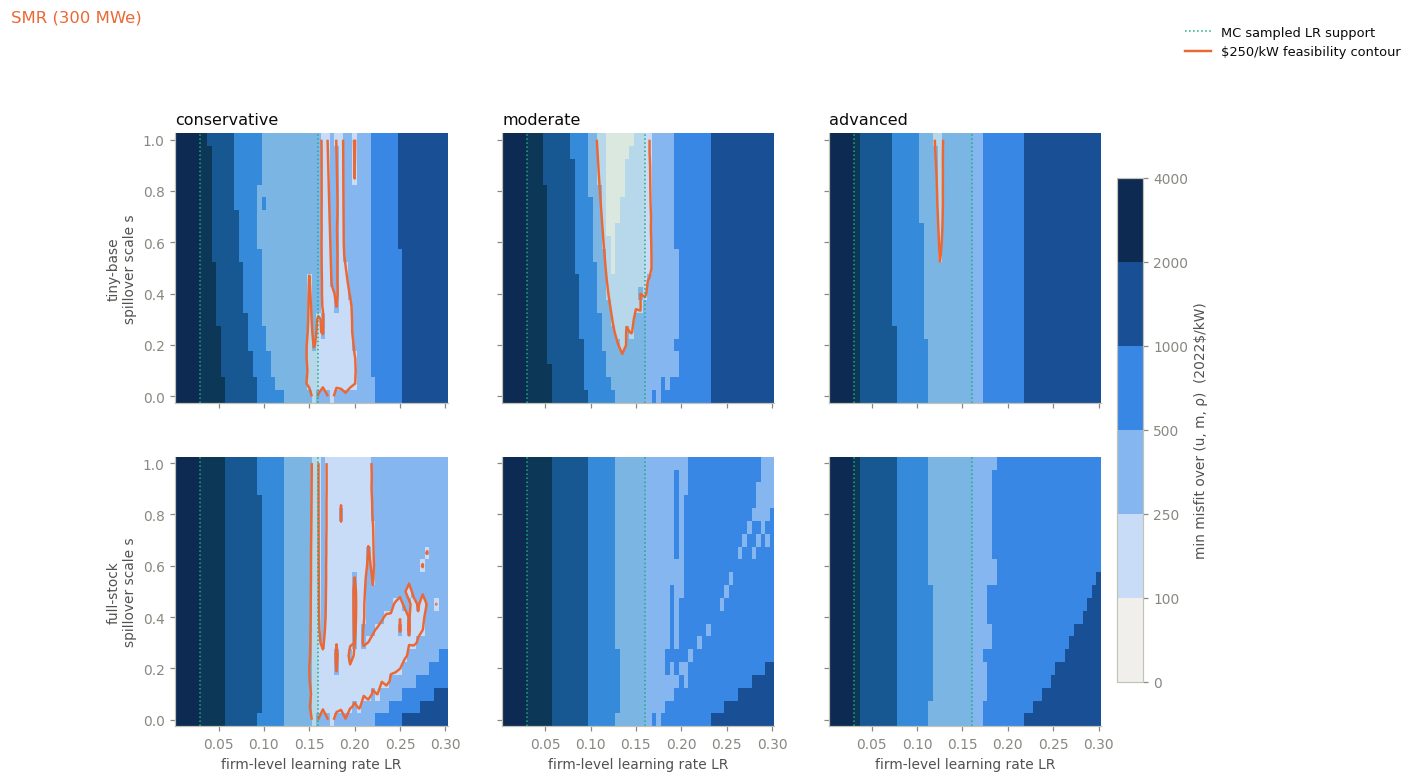

In [11]:
# F3 - feasible-region maps in the (LR, s) plane, minimized over (u, m, rho), by experience base.
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

_levels = [0, 100, 250, 500, 1000, 2000, 4000]
_norm = BoundaryNorm(_levels, CMAP_SEQ.N)

for tech in TECH:
    fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharex=True, sharey=True)
    for r, conv_name, conv_val in [(0, "tiny-base", 0), (1, "full-stock", 1)]:
        for c, scen in enumerate(SCEN_ORDER):
            ax = axes[r, c]
            g = FITS[(tech, scen)]["mis"].reshape(GRID_SHAPE)          # (rho,conv,m,lr,s,u)
            zmin = g[:, conv_val].min(axis=(0, 1, 4))                  # (lr, s)
            pc = ax.pcolormesh(LR_GRID, S21, zmin.T, cmap=CMAP_SEQ, norm=_norm,
                               shading="nearest")
            ax.grid(False)                                             # house heatmap rule
            if (zmin <= TOL).any():
                ax.contour(LR_GRID, S21, zmin.T, levels=[TOL], colors=[C_SMR], linewidths=1.6)
            ax.axvspan(TECH[tech]["lr_lo"], TECH[tech]["lr_hi"], color=C_TINY, alpha=0.10, lw=0)
            for x in (TECH[tech]["lr_lo"], TECH[tech]["lr_hi"]):
                ax.axvline(x, color=C_TINY, lw=1.0, ls=":")
            if r == 0:
                ax.set_title(scen, fontsize=10.5)
            if c == 0:
                ax.set_ylabel(f"{conv_name}\nspillover scale s")
            if r == 1:
                ax.set_xlabel("firm-level learning rate LR")
    # No baked paper letters since 08-24: Fig 1 now composes F8 + F9 (endpoint basis);
    # this milestone-criterion map stays a notebook diagnostic.
    # Legend glyph matches the drawing: the LR support reads as the dotted edge lines
    # (the alpha-0.10 span is invisible over the heatmap), so the key shows a dotted line.
    handles = [Line2D([], [], color=C_TINY, lw=1.0, ls=":", label="MC sampled LR support"),
               Line2D([], [], color=C_SMR, lw=1.6, label=f"${TOL:.0f}/kW feasibility contour")]
    fig.legend(handles=handles, loc="upper right", fontsize=8.5, bbox_to_anchor=(0.99, 1.035))
    cb = fig.colorbar(pc, ax=axes, shrink=0.85, pad=0.015)
    cb.set_label("min misfit over (u, m, ρ)  (2022$/kW)")
    fig.suptitle(TECH_LABEL[tech], color=TECH_COLOR[tech], x=0.01, ha="left", y=1.04)
    ps.savefig(fig, FIGURES / f"atb_feasible_maps_{tech}.png")
    plt.show()

saved -> figures\atb_dial_marginals_large.png


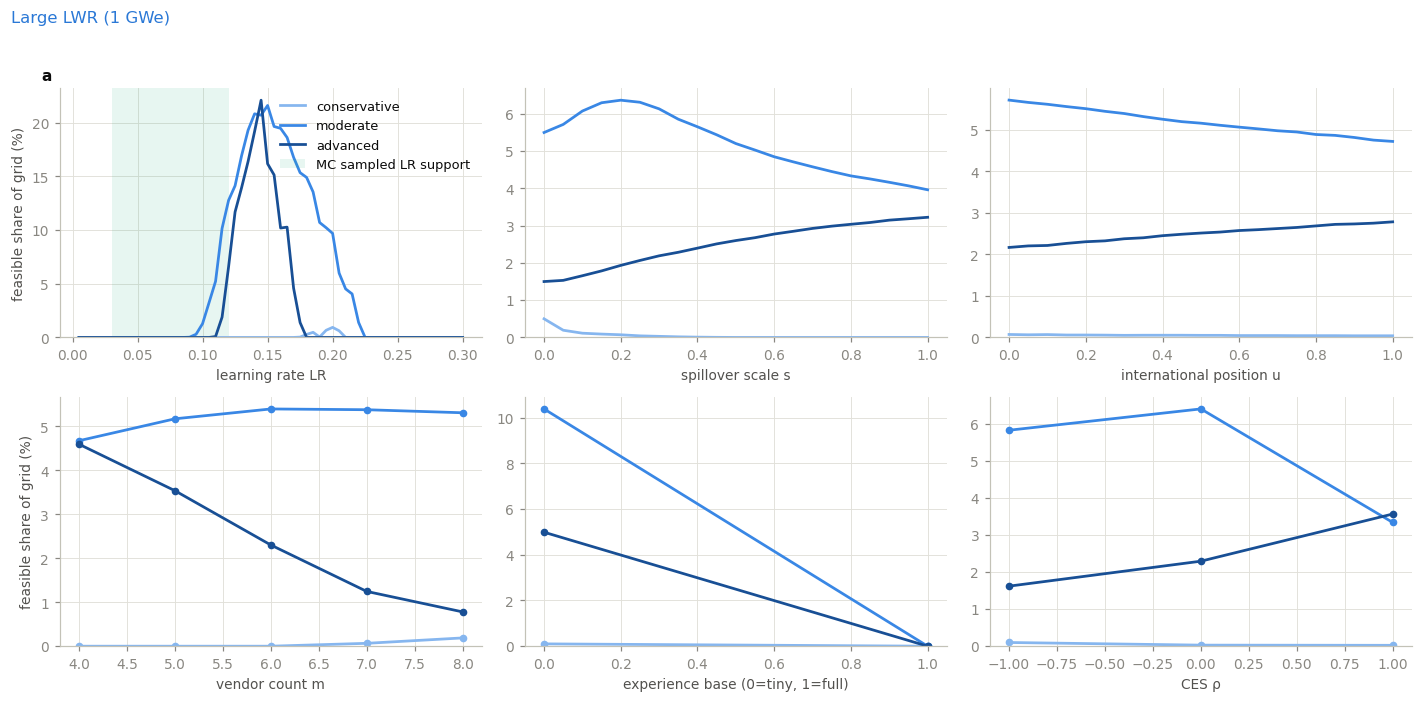

saved -> figures\atb_dial_marginals_smr.png


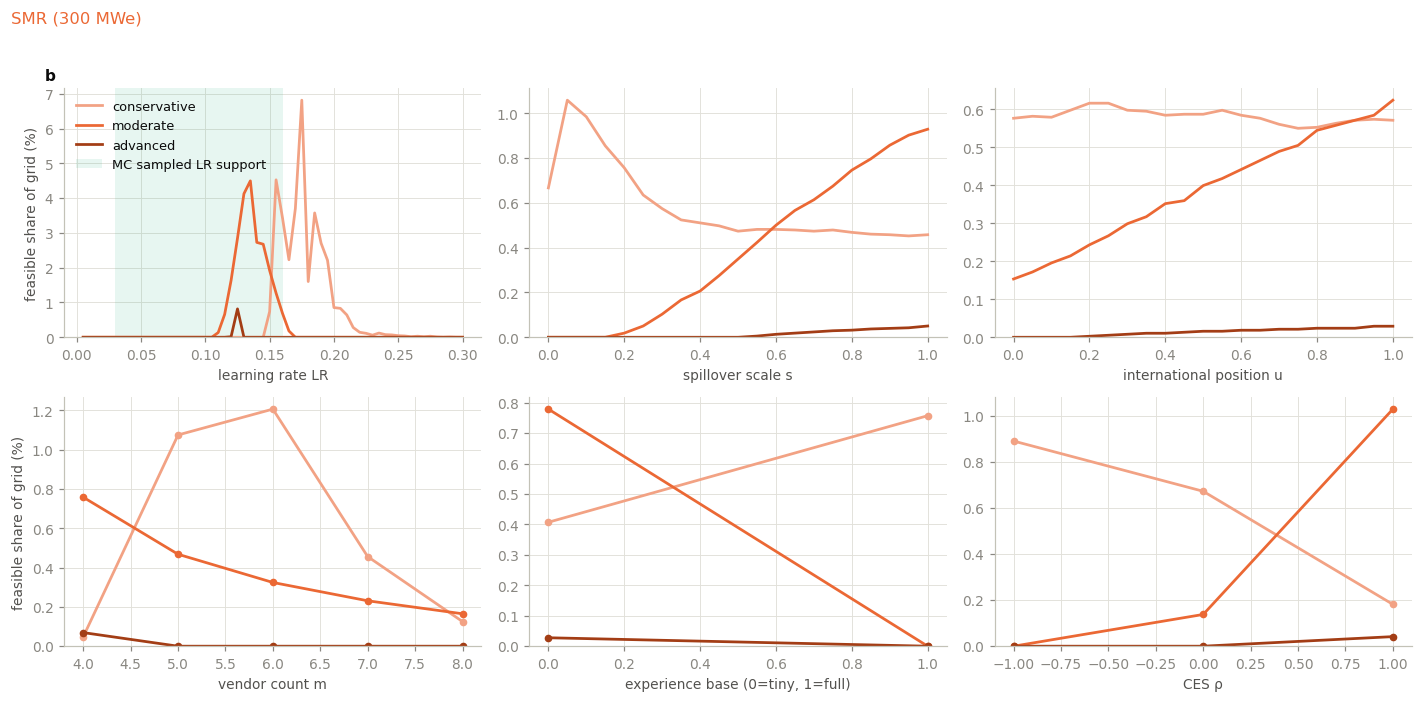

In [12]:
# F4 - marginal feasibility profiles: which dials does the ATB target actually constrain?
# For each dial value: share of feasible worlds among all grid worlds holding that value.
_AXIS = {"ces_rho": 0, "conv_full": 1, "n_vendors": 2, "lr": 3, "s": 4, "u": 5}
_VALS = {"ces_rho": CES_RHO_GRID, "conv_full": CONV_GRID, "n_vendors": M_GRID,
         "lr": LR_GRID, "s": S21, "u": U21}
_XLAB = {"lr": "learning rate LR", "s": "spillover scale s", "u": "international position u",
         "n_vendors": "vendor count m", "conv_full": "experience base (0=tiny, 1=full)",
         "ces_rho": "CES ρ"}

for tech in TECH:
    fig, axes = plt.subplots(2, 3, figsize=(13, 6.2))
    for ax, dial in zip(axes.ravel(), ["lr", "s", "u", "n_vendors", "conv_full", "ces_rho"]):
        ax_i = _AXIS[dial]
        other = tuple(i for i in range(6) if i != ax_i)
        for scen in SCEN_ORDER:
            feas = (FITS[(tech, scen)]["mis"] <= TOL).reshape(GRID_SHAPE)
            frac = 100.0 * feas.mean(axis=other)
            ax.plot(_VALS[dial], frac, color=SCEN_COLOR[tech][scen], lw=1.8,
                    marker="o" if dial in ("ces_rho", "conv_full", "n_vendors") else None,
                    ms=4, label=scen)
        if dial == "lr":
            ax.axvspan(TECH[tech]["lr_lo"], TECH[tech]["lr_hi"], color=C_TINY, alpha=0.10, lw=0,
                       label="MC sampled LR support")
        ax.set_xlabel(_XLAB[dial])
        ax.set_ylim(bottom=0)
    axes[0, 0].set_ylabel("feasible share of grid (%)")
    axes[1, 0].set_ylabel("feasible share of grid (%)")
    axes[0, 0].legend(fontsize=8.5)
    fig.suptitle(TECH_LABEL[tech], color=TECH_COLOR[tech], x=0.01, ha="left", y=1.02)
    # SF16 pastes these two figures side by side; letters are stamped at source ("a" large,
    # "b" smr) because composition-level letters collided with the tech block titles.
    ps.panel_letter(axes[0, 0], "a" if tech == "large" else "b")
    fig.tight_layout()
    ps.savefig(fig, FIGURES / f"atb_dial_marginals_{tech}.png")
    plt.show()

saved -> figures\atb_cross_pairing.png


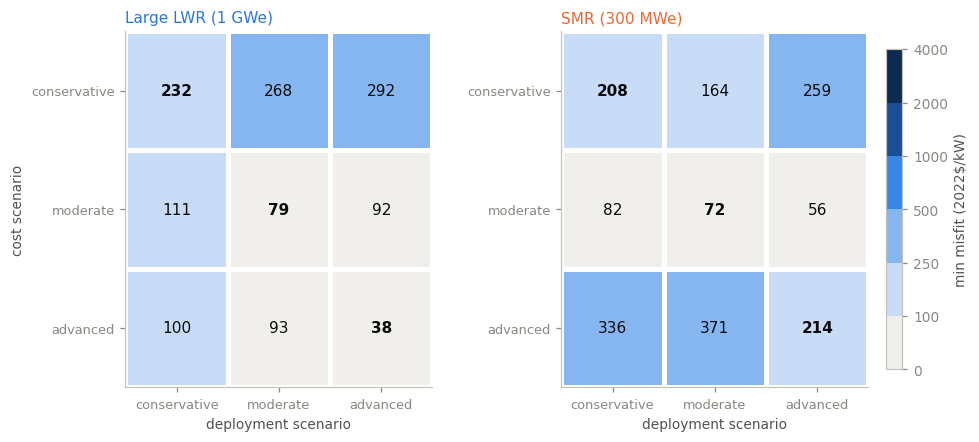

wrote exports/atb/cross_pairing_misfit.csv (rows = cost scenario, cols = deployment)


In [13]:
# F5 - the 3x3 cross-pairing check: min achievable misfit for every cost x deployment pairing.
# The matched diagonal should be (near) the row minimum if the source's pairing is coherent;
# off-diagonal cells price what it would take for, say, advanced costs at moderate deployment.
cross = {}
for tech in TECH:
    mat = np.empty((3, 3))
    for i, cost_scen in enumerate(SCEN_ORDER):
        for j, dep_scen in enumerate(SCEN_ORDER):
            mat[i, j] = misfit(tech, cost_scen, dep_scen).min()
    cross[tech] = mat

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2))
_levels5 = [0, 100, 250, 500, 1000, 2000, 4000]
_norm5 = BoundaryNorm(_levels5, CMAP_SEQ.N)
for ax, tech in zip(axes, TECH):
    mat = cross[tech]
    pc = ax.pcolormesh(np.arange(4), np.arange(4), mat, cmap=CMAP_SEQ, norm=_norm5,
                       edgecolors=SURFACE, linewidth=2)
    for i in range(3):
        for j in range(3):
            dark = mat[i, j] >= 500
            ax.text(j + 0.5, i + 0.5, f"{mat[i, j]:,.0f}", ha="center", va="center",
                    fontsize=10, color=SURFACE if dark else INK,
                    fontweight="bold" if i == j else "normal")
    ax.set_xticks(np.arange(3) + 0.5, SCEN_ORDER, fontsize=8.5)
    ax.set_yticks(np.arange(3) + 0.5, SCEN_ORDER, fontsize=8.5)
    ax.set_xlabel("deployment scenario")
    ax.set_ylabel("cost scenario" if tech == "large" else None)
    ax.set_title(TECH_LABEL[tech], color=TECH_COLOR[tech])
    ax.invert_yaxis()
    ax.grid(False)
# Widen the panel gap so the right panel's scenario tick labels clear the left panel.
fig.subplots_adjust(wspace=0.42)
fig.colorbar(pc, ax=axes, shrink=0.9, pad=0.02).set_label("min misfit (2022$/kW)")
ps.savefig(fig, FIGURES / "atb_cross_pairing.png")
plt.show()

pd.concat({t: pd.DataFrame(cross[t], index=SCEN_ORDER, columns=SCEN_ORDER).round(0)
           for t in TECH}, names=["tech", "cost_scenario"]) \
    .to_csv(ATB_OUT / "cross_pairing_misfit.csv")
print("wrote exports/atb/cross_pairing_misfit.csv (rows = cost scenario, cols = deployment)")

## A6 — Part 2: the 2050 endpoint with deployment free

**Why deployment collapses to one number.** The engine is *memoryless in the path*: the OCC in
year t is a function of the cumulative experience stocks **at t** only —

$$\mathrm{OCC}(t) \;=\; \mathrm{BOAK}\cdot\Big(\tfrac{E(O(t),\,A(t))}{E(O(2030),\,A(2030))}\Big)^{-b},$$

with own-stock $O(t) = \mathrm{own}_0 + N_{us}(t)/m$
and cross-stock
$A(t) = (m{-}1)\,\mathrm{own}_0 + N_{us}(t)\,(m{-}1)/m + s\,(H_{KV} + S_{KV}(t))$
— the companion engine (S5 Step 5): the θ·s-weighted foreign stock, unsplit across
technologies, sits in the cross-firm channel; no other-tech US program appears in these
single-technology fits, so the drawn cross-tech x never enters.
Every deployment path with the same cumulative build $N_{us}(2050)$ therefore produces the *same*
2050 cost, no matter how the builds are timed (QA-5 verifies this through the full engine). So
"what deployment achieves the ATB 2050 cost?" has a well-defined scalar answer per parameter
world: the **required cumulative new build D (GW by 2050)**, found by bisection on the closed-form
2050 evaluation (OCC(2050) is strictly decreasing in D).

**Conventions.** BOAK stays pinned at the ATB scenario's 2030 anchor in the primary read — the
question is "what deployment delivers *this ATB curve's* endpoint from *its own* starting point."
A sensitivity band lets BOAK float across the MC's sampled anchor range instead (F7). Two boundary
outcomes are tracked explicitly and shown hatched/censored in the figures:

- **D = 0** — international spillover alone (u, s) already delivers the 2050 target;
- **unreachable** — even 10,000 GW by 2050 does not reach the target (slow learning, flat curve).

The structural echo of Part 1: Part 1 asked *which parameters* work at a fixed deployment;
Part 2 asks *how much deployment* each parameter world needs. The two are slices of the same
(parameters × deployment) feasibility surface.

In [14]:
# The closed-form 2050 evaluator (single-year restriction of occ_paths_ces), and QA-5.
I2050 = yi(2050)

def skv_2050(u):
    """Theta-weighted foreign stock ENTERING the 2050 price, per world: builds through 2049
    (the engine's one-year completion lag), post-anchor basis (years <= 2030 zeroed);
    unsplit across technologies (the cross-firm channel does not distinguish designs)."""
    gi = np.clip(np.rint(np.asarray(u, float) * (len(U_GRID)-1)).astype(int), 0, len(U_GRID)-1)
    return sum(THETA_KV[r] * REGION_STOCK[r][gi, I2050 - 1] for r in REGIONS)

def shape_2050(tech, lr, s, u, m, conv, rho, n2050):
    """OCC(2050)/BOAK for a post-anchor stock of n2050 units ENTERING the 2050 price (builds
    completed through 2049, per the engine's one-year lag) - vectorized over worlds.
    Identical algebra to occ_paths_ces restricted to the 2050 and anchor columns: the
    theta*s-weighted foreign stock (and, under full-stock, the all-LWR historical fleet)
    sits in the cross-firm channel, unsplit across technologies (companion S5 Step 5).
    No other-tech US program appears here (Part 2 prices a single technology's deployment;
    n_oth stays None throughout), so the drawn cross-tech x never enters."""
    lr, s, m, conv, rho, n2050 = np.broadcast_arrays(
        *[np.asarray(a, float) for a in (lr, s, m, conv, rho, n2050)])
    skv = np.broadcast_to(skv_2050(u), lr.shape)
    hist_us = HIST_UNITS["US"] if tech == "large" else 0.0
    H_kv = conv*H_ALL_W                                  # foreign historical: both techs alike
    own0 = N_BOAK_UNITS + conv*hist_us/m
    ownA = own0
    own50 = own0 + n2050/m
    othA = (m-1.0)*own0 + s*H_kv                         # S_KV at the anchor is 0
    oth50 = (m-1.0)*own0 + n2050*(m-1.0)/m + s*(H_kv + skv)
    b1, b2 = np.log2(1.0 - lr), np.log2(1.0 - OMEGA*lr)
    b, w = -(b1 + b2), b1/(b1 + b2)
    geo = np.abs(rho) < CES_EPS
    rho_safe = np.where(geo, 1.0, rho)
    def _lnE(o, a):
        lnO, lnA = np.log(o), np.log(a)
        return np.where(geo, w*lnO + (1.0-w)*lnA,
                        lnO + np.log1p((1.0-w)*np.expm1(rho_safe*(lnA - lnO)))/rho_safe)
    return np.exp(-b*(_lnE(own50, oth50) - _lnE(ownA, othA)))

# --- QA-5a: the closed form equals the full engine's 2050 column (random worlds, both techs)
_rng5 = rng_stream("atb/qa5")
_n5 = 400
_qa = {k: _rng5.uniform(*b, _n5) for k, b in
       [("lr", (0.005, 0.30)), ("s", (0, 1)), ("u", (0, 1))]}
_qa["m"] = _rng5.integers(4, 9, _n5).astype(float)
_qa["conv"] = _rng5.integers(0, 2, _n5).astype(float)
_qa["rho"] = _rng5.choice(CES_RHO_GRID, _n5)
for tech in TECH:
    n2050 = _rng5.uniform(0.0, 3000.0, _n5)
    for i in range(0, _n5, 50):      # engine takes one n_us per call -> spot-check 8 worlds/tech
        sl = slice(i, i + 1)
        ramp = np.where(YEARS <= ANCHOR, 0.0, (YEARS - ANCHOR)/(2050.0 - ANCHOR)) * n2050[i]
        w1 = make_worlds(_qa["lr"][sl], 1.0, _qa["u"][sl], _qa["s"][sl],
                         _qa["m"][sl], _qa["conv"][sl], _qa["rho"][sl])
        full = occ_paths_ces(w1, tech, ramp)[0, I2050]
        closed = shape_2050(tech, _qa["lr"][sl], _qa["s"][sl], _qa["u"][sl], _qa["m"][sl],
                            _qa["conv"][sl], _qa["rho"][sl],
                            np.array([ramp[I2050 - 1]]))[0]     # stock ENTERING 2050
        assert abs(full - closed) < 1e-10, (tech, i, full, closed)
print("QA-5a PASSED: closed-form 2050 evaluator == full engine's 2050 column "
      "(8 random worlds x both techs x linear-ramp schedules)")

# --- QA-5b: path invariance - different build timings, same cumulative 2050 stock, same OCC(2050)
_w5 = make_worlds([0.11], 1.0, [0.6], [0.5], [5.0], [0.0], [-1.0])
# Equal cumulative stock ENTERING 2050 (= builds through 2049, the engine's lag) under
# three different timings; the 2050 price must agree.
_lin = np.minimum(np.where(YEARS <= ANCHOR, 0.0, (YEARS - ANCHOR)/19.0), 1.0) * 300.0
_late = np.minimum(np.where(YEARS <= 2044, 0.0, (YEARS - 2044)/5.0), 1.0) * 300.0   # builds 2045-2049
_early = np.minimum(np.where(YEARS <= ANCHOR, 0.0, (YEARS - ANCHOR)/5.0), 1.0) * 300.0
_v = [occ_paths_ces(_w5, "smr", p)[0, I2050] for p in (_lin, _late, _early)]
assert np.ptp(_v) < 1e-12, _v
print(f"QA-5b PASSED: OCC(2050) is path-invariant at fixed cumulative completed build "
      f"(linear / back-loaded / front-loaded schedules agree to {np.ptp(_v):.1e})")

# --- QA-5c: monotonicity in the cumulative build (validates bisection)
_Ns = np.logspace(-2, 4.5, 300)
for tech in TECH:
    sh = shape_2050(tech, 0.08, 0.5, 0.5, 6.0, 0.0, 0.0, _Ns)
    assert (np.diff(sh) < 0).all(), tech
    sh_full = shape_2050(tech, 0.08, 0.5, 0.5, 6.0, 1.0, 0.0, _Ns)
    assert (np.diff(sh_full) < 0).all(), tech
print("QA-5c PASSED: OCC(2050) strictly decreasing in cumulative build (both techs, both bases)")

QA-5a PASSED: closed-form 2050 evaluator == full engine's 2050 column (8 random worlds x both techs x linear-ramp schedules)
QA-5b PASSED: OCC(2050) is path-invariant at fixed cumulative completed build (linear / back-loaded / front-loaded schedules agree to 0.0e+00)
QA-5c PASSED: OCC(2050) strictly decreasing in cumulative build (both techs, both bases)


In [15]:
# Solve for the required deployment D (GW by 2050) across the parameter grid, by bisection.
D_MAX_GW = 10000.0               # censoring bound: "even 10 TW doesn't get there"

def required_gw(tech, ratio, lr, s, u, m, conv, rho):
    """GW of cumulative post-anchor new build, completed through 2049 (the stock that
    prices 2050 under the engine's lag), needed for OCC(2050)/BOAK <= ratio.
    Returns 0 where international spillover alone suffices, inf where censored at D_MAX_GW."""
    lr, s, u, m, conv, rho, ratio = (np.atleast_1d(a) for a in np.broadcast_arrays(
        *[np.asarray(a, float) for a in (lr, s, u, m, conv, rho, ratio)]))
    n_hi = np.full(lr.shape, D_MAX_GW / TECH[tech]["unit_gw"])
    out = np.full(lr.shape, np.nan)
    sh0 = shape_2050(tech, lr, s, u, m, conv, rho, 0.0)
    sh_hi = shape_2050(tech, lr, s, u, m, conv, rho, n_hi)
    out[sh0 <= ratio] = 0.0
    out[sh_hi > ratio] = np.inf
    todo = np.isnan(out)
    if todo.any():
        lo = np.zeros(todo.sum())
        hi = n_hi[todo]
        args = [a[todo] for a in (lr, s, u, m, conv, rho)]
        target = ratio[todo]
        for _ in range(70):
            mid = 0.5*(lo + hi)
            above = shape_2050(tech, *args, mid) > target
            lo = np.where(above, mid, lo)
            hi = np.where(above, hi, mid)
        out[todo] = 0.5*(lo + hi)*TECH[tech]["unit_gw"]
    return out

# Part-2 grid: LR x s x u3 per discrete combo (u collapses to three named worlds)
U3 = np.array([0.0, 0.5, 1.0])
_m2 = np.meshgrid(LR_GRID, S21, U3, indexing="ij")
LR2, S2, U2 = (a.ravel() for a in _m2)
NP2 = LR2.size
P2_SHAPE = (len(CES_RHO_GRID), len(CONV_GRID), len(M_GRID), len(LR_GRID), len(S21), len(U3))

REQ_D = {}       # REQ_D[(tech, scen)] -> (n_combos*NP2,) required GW, boak pinned at the ATB anchor
_t0 = _time.time()
for tech in TECH:
    for scen in SCEN_ORDER:
        ratio = TARGET[tech][scen][-1] / BOAK_PIN[tech][scen]
        req = np.empty(len(DISC_COMBOS)*NP2)
        for ci, (rho, conv, m) in enumerate(DISC_COMBOS):
            req[ci*NP2:(ci+1)*NP2] = required_gw(tech, ratio, LR2, S2, U2, m, conv, rho)
        REQ_D[(tech, scen)] = req
print(f"required-deployment surfaces solved for {len(REQ_D)} tech x scenario targets "
      f"({len(DISC_COMBOS)*NP2:,} worlds each) in {_time.time()-_t0:.0f}s")

# QA-6: plugging the solution back in reproduces the target ratio (finite, nonzero solutions)
_rngq = rng_stream("atb/qa6")
for (tech, scen), req in REQ_D.items():
    fin = np.flatnonzero(np.isfinite(req) & (req > 0))
    if fin.size == 0:
        continue
    pick = _rngq.choice(fin, size=min(200, fin.size), replace=False)
    ci, k = np.divmod(pick, NP2)
    rho = np.array([DISC_COMBOS[c][0] for c in ci])
    conv = np.array([DISC_COMBOS[c][1] for c in ci])
    m = np.array([DISC_COMBOS[c][2] for c in ci])
    sh = shape_2050(tech, LR2[k], S2[k], U2[k], m, conv, rho,
                    req[pick]/TECH[tech]["unit_gw"])
    ratio = TARGET[tech][scen][-1] / BOAK_PIN[tech][scen]
    assert np.abs(sh - ratio).max() < 1e-6, (tech, scen)
print("QA-6 PASSED: bisection solutions reproduce their target 2050 ratio to <1e-6 "
      "(200 random finite solutions per fit)")

# T4 - required deployment at literature anchor points (u = 0.5, rho = 0)
_anchors = [("Abou-Jaoude (LR 9.5%, m=4, tiny, s=0)", dict(lr=0.095, s=0.0, m=4.0, conv=0.0)),
            ("MC central, tiny base (LR mid-support, m=6, s=0.5)", None),   # lr set per tech below
            ("MC central, full stock", None)]
_rows = []
for tech in TECH:
    lr_mid = 0.5*(TECH[tech]["lr_lo"] + TECH[tech]["lr_hi"])
    settings = [(_anchors[0][0], _anchors[0][1]),
                (_anchors[1][0], dict(lr=lr_mid, s=0.5, m=6.0, conv=0.0)),
                (_anchors[2][0], dict(lr=lr_mid, s=0.5, m=6.0, conv=1.0))]
    for scen in SCEN_ORDER:
        ratio = TARGET[tech][scen][-1] / BOAK_PIN[tech][scen]
        row = {"tech": tech, "scenario": scen, "AJ deployment (GW)": AJ_GW_POST[scen],
               "AJ completed through 2049 (GW)": round(AJ_GW_ENT50[scen], 1)}
        for name, st in settings:
            d = required_gw(tech, ratio, st["lr"], st["s"], 0.5,
                            st["m"], st["conv"], 0.0).item()
            row[name] = round(d, 1) if np.isfinite(d) else np.inf
        _rows.append(row)
req_anchors = pd.DataFrame(_rows).set_index(["tech", "scenario"])
req_anchors.to_csv(ATB_OUT / "required_deployment_anchors.csv")
print("\nT4 - required post-2030 build completed through 2049 (GW - the stock that prices "
      "2050) to hit the ATB 2050 cost, at literature anchor worlds (u=0.5, rho=0) "
      "-> exports/atb/required_deployment_anchors.csv")
print(req_anchors.to_string())

# T5 - the inverse read: minimum LR that reaches the ATB 2050 cost at the paired AJ deployment
_rows = []
for tech in TECH:
    for scen in SCEN_ORDER:
        ratio = TARGET[tech][scen][-1] / BOAK_PIN[tech][scen]
        n50 = AJ_GW_ENT50[scen] / TECH[tech]["unit_gw"]   # scoring basis: builds thru 2049
        for conv in (0.0, 1.0):
            row = {"tech": tech, "scenario": scen,
                   "base": "full" if conv else "tiny"}
            for s_val in (0.0, 0.5, 1.0):
                sh = shape_2050(tech, LR_GRID, s_val, 0.5, 6.0, conv, 0.0, n50)
                ok = np.flatnonzero(sh <= ratio)
                row[f"min LR @ s={s_val}"] = LR_GRID[ok[0]] if ok.size else np.nan
            _rows.append(row)
min_lr = pd.DataFrame(_rows).set_index(["tech", "scenario", "base"])
min_lr.to_csv(ATB_OUT / "min_lr_at_aj_deployment.csv")
print("\nT5 - minimum firm-level LR to reach the ATB 2050 cost at the paired deployment, "
      "scored on the through-2049 stock that prices 2050 (m=6, u=0.5, rho=0; NaN = "
      "unreachable even at LR 30%) -> exports/atb/min_lr_at_aj_deployment.csv")
print(min_lr.to_string())

required-deployment surfaces solved for 6 tech x scenario targets (113,400 worlds each) in 26s
QA-6 PASSED: bisection solutions reproduce their target 2050 ratio to <1e-6 (200 random finite solutions per fit)



T4 - required post-2030 build completed through 2049 (GW - the stock that prices 2050) to hit the ATB 2050 cost, at literature anchor worlds (u=0.5, rho=0) -> exports/atb/required_deployment_anchors.csv
                    AJ deployment (GW)  AJ completed through 2049 (GW)  Abou-Jaoude (LR 9.5%, m=4, tiny, s=0)  MC central, tiny base (LR mid-support, m=6, s=0.5)  MC central, full stock
tech  scenario                                                                                                                                                                           
large conservative                12.0                            10.8                                   22.7                                                47.8                   713.1
      moderate                    33.0                            29.6                                   67.5                                               191.4                  2615.0
      advanced                   199.0              

**F6 — required-deployment maps** (`atb_required_deployment_maps_{tech}.png`, one figure per technology). Post-2030 build completed through 2049 (GW, log color scale — the stock that prices 2050
under the engine's one-year lag) required to reach each ATB scenario's 2050 cost, over learning rate × spillover at the central discrete world (m = 6, ρ = 0, u = 0.5), tiny-base vs full-stock rows. Hatched = unreachable even at 10 TW; the orange contour marks the paired Abou-Jaoude program on the same through-2049 basis (worlds left of it need more than the AJ program); the green band is the MC's sampled LR support. Column heads carry each scenario's 2050 target.

saved -> figures\atb_required_deployment_maps_large.png


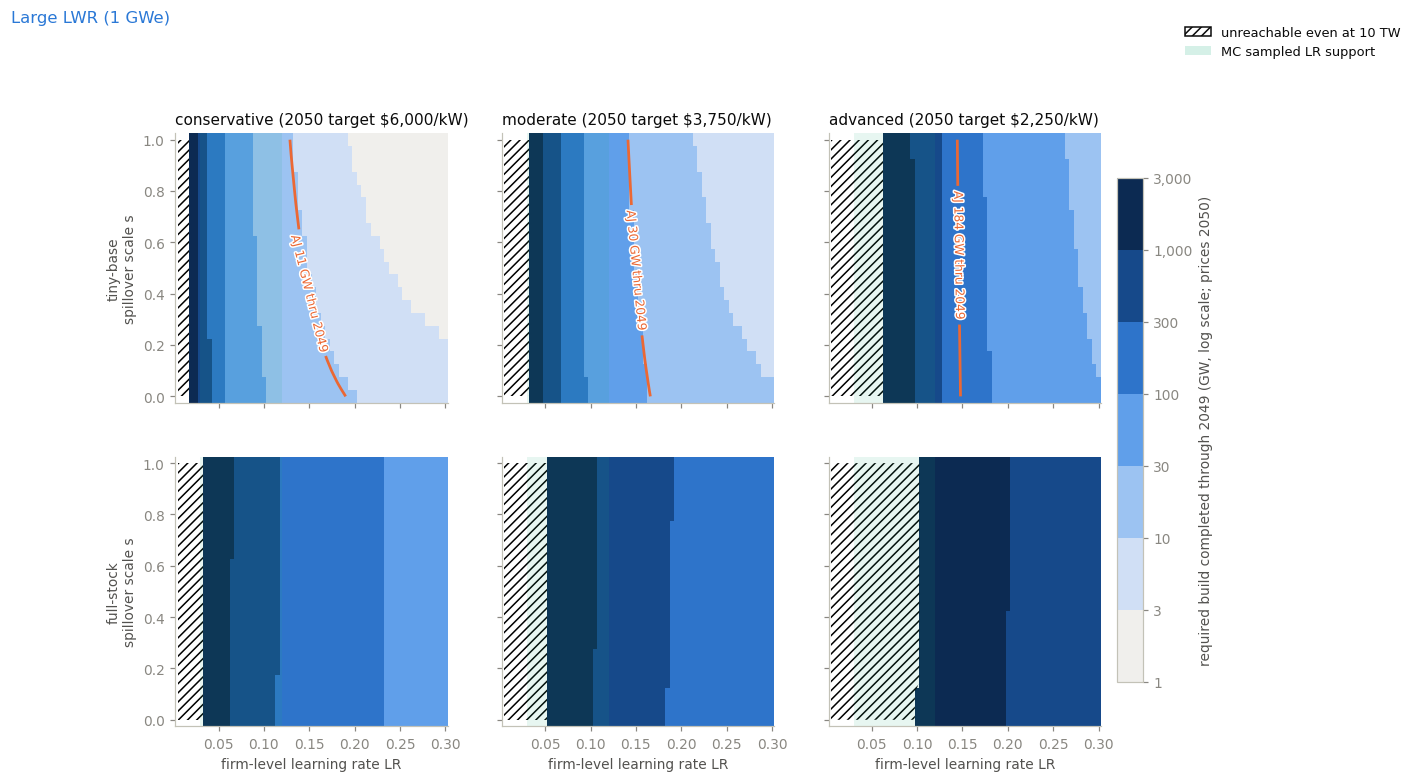

saved -> figures\atb_required_deployment_maps_smr.png


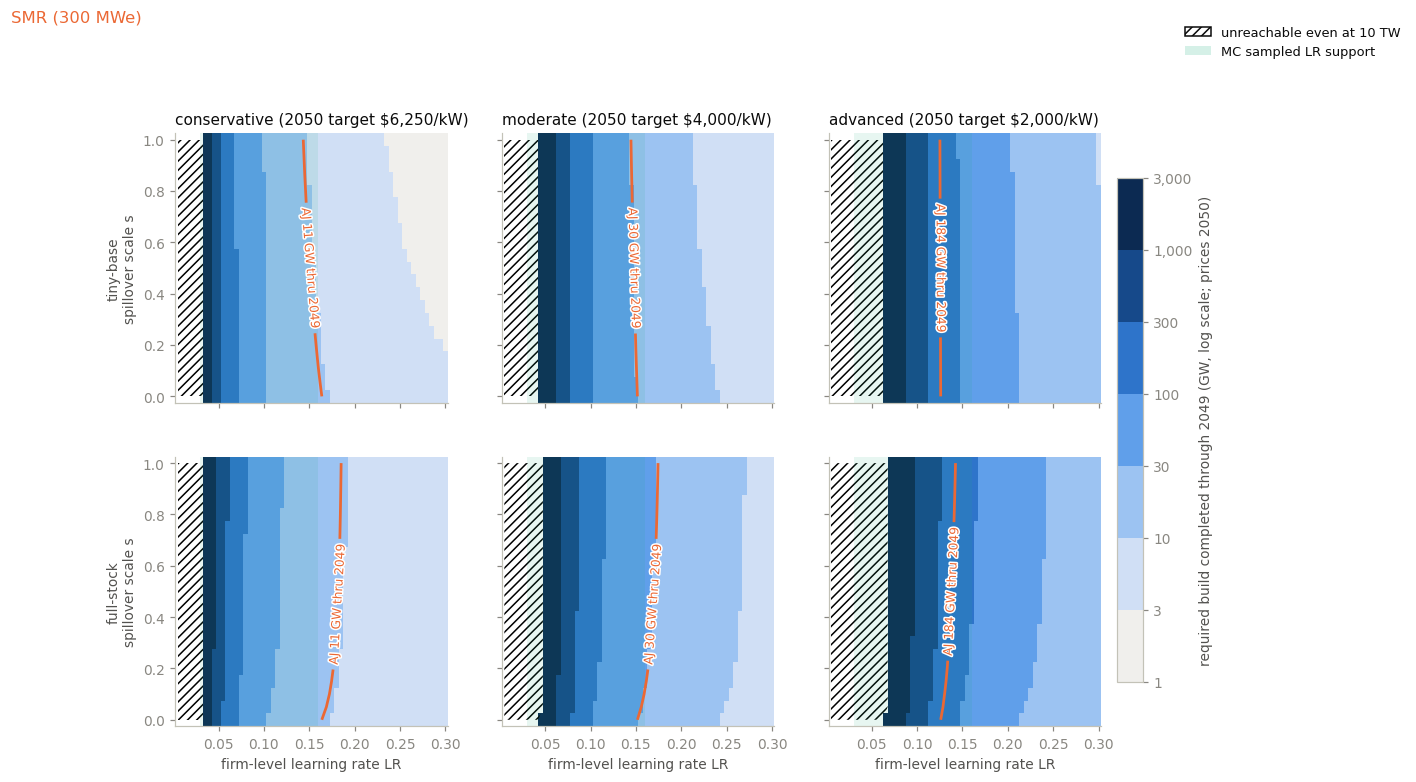

In [16]:
# F6 - required-deployment contour maps over (LR, s), at the central discrete world
# (m = 6, rho = 0, u = 0.5), tiny-base vs full-stock. The orange contour marks the
# Abou-Jaoude deployment paired with that scenario: parameter worlds on it need exactly
# the AJ program; worlds left of it need more than AJ; hatched = unreachable at 10 TW.
import matplotlib.patheffects as _pe
_ci_center = {(rho, conv, m): i for i, (rho, conv, m) in enumerate(DISC_COMBOS)}
_lev = [1, 3, 10, 30, 100, 300, 1000, 3000]
_normd = BoundaryNorm(np.log10(_lev), CMAP_SEQ.N)

for tech in TECH:
    fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharex=True, sharey=True)
    for r, conv in enumerate(CONV_GRID):
        for c, scen in enumerate(SCEN_ORDER):
            ax = axes[r, c]
            ci = _ci_center[(0.0, conv, 6.0)]
            g = REQ_D[(tech, scen)][ci*NP2:(ci+1)*NP2].reshape(len(LR_GRID), len(S21), len(U3))
            z = g[:, :, 1]                                   # u = 0.5 slice
            zplot = np.where(z <= 0, 0.5, z)                 # D = 0 -> below the first level
            zma = np.ma.masked_invalid(np.where(np.isinf(zplot), np.nan, zplot))
            pc = ax.pcolormesh(LR_GRID, S21, np.ma.log10(zma).T,
                               cmap=CMAP_SEQ, norm=_normd, shading="nearest")
            ax.grid(False)                                             # house heatmap rule
            if np.isinf(z).any():
                ax.contourf(LR_GRID, S21, np.isinf(z).T.astype(float), levels=[0.5, 1.5],
                            colors="none", hatches=["////"])
            if np.isfinite(z).any() and (z <= AJ_GW_ENT50[scen]).any() \
                    and (np.where(np.isinf(z), 1e9, z) >= AJ_GW_ENT50[scen]).any():
                cs = ax.contour(LR_GRID, S21, np.where(np.isinf(z), 1e9, z).T,
                                levels=[AJ_GW_ENT50[scen]], colors=[C_SMR], linewidths=1.8)
                for txt in ax.clabel(cs, fmt=lambda v: f"AJ {v:,.0f} GW thru 2049", fontsize=8):
                    txt.set_path_effects([_pe.withStroke(linewidth=2, foreground=SURFACE)])
            ax.axvspan(TECH[tech]["lr_lo"], TECH[tech]["lr_hi"], color=C_TINY, alpha=0.10, lw=0)
            if r == 0:
                ax.set_title(f"{scen} (2050 target ${TARGET[tech][scen][-1]:,.0f}/kW)",
                             fontsize=10)
            if c == 0:
                ax.set_ylabel(("tiny-base" if conv == 0 else "full-stock") + "\nspillover scale s")
            if r == 1:
                ax.set_xlabel("firm-level learning rate LR")
    cb = fig.colorbar(pc, ax=axes, shrink=0.85, pad=0.015,
                      ticks=np.log10(_lev))
    cb.set_ticklabels([f"{v:,}" for v in _lev])
    cb.set_label("required build completed through 2049 (GW, log scale; prices 2050)")
    fig.suptitle(TECH_LABEL[tech], color=TECH_COLOR[tech], x=0.01, ha="left", y=1.04)
    # Key for the two unlabeled encodings: hatching marks worlds where required_gw is inf
    # (the ATB 2050 cost is unreachable even at the D_MAX_GW = 10 TW censoring bound);
    # the pale band is the MC sampled LR support.
    from matplotlib.patches import Patch as _Patch
    fig.legend(handles=[
        _Patch(facecolor="none", edgecolor=INK, hatch="////",
               label=f"unreachable even at {D_MAX_GW/1000:.0f} TW"),
        _Patch(facecolor=C_TINY, alpha=0.18, label="MC sampled LR support")],
        loc="upper right", frameon=False, fontsize=8.5, bbox_to_anchor=(0.99, 1.035))
    ps.savefig(fig, FIGURES / f"atb_required_deployment_maps_{tech}.png")
    plt.show()

**F7 — required deployment vs learning rate** (`atb_required_deployment_vs_lr.png`). Tiny-base, m = 6, ρ = 0, u = 0.5; spillover s ∈ {0, 0.5, 1} as lightness steps of the tech hue. The shaded band floats BOAK across the MC anchor range at s = 0.5; the dashed line is the paired Abou-Jaoude program (through-2049 basis), the dotted line the 2024 US fleet (97 GW), and the green band the MC's sampled LR support.

saved -> figures\atb_required_deployment_vs_lr.png


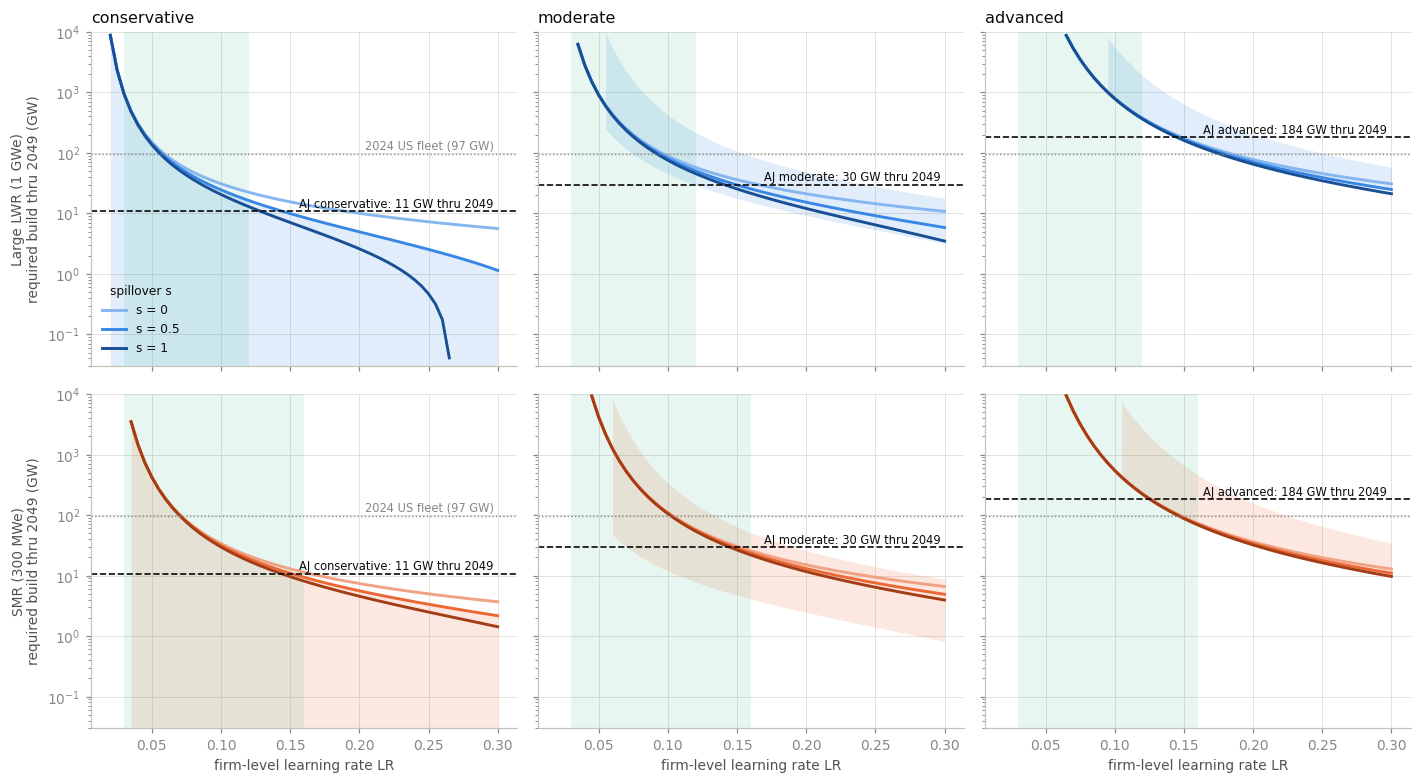

In [17]:
# F7 - required deployment vs learning rate, with the BOAK-float band and reference lines.
# Tiny-base, m = 6, rho = 0, u = 0.5; s in {0, 0.5, 1} as lightness steps of the tech hue.
_S_STEPS = [0.0, 0.5, 1.0]
_S_COLS = {"large": ["#86b6ef", "#3987e5", "#184f95"], "smr": ["#f2a284", "#eb6834", "#a33d15"]}

fig, axes = plt.subplots(2, 3, figsize=(13, 7.2), sharex=True, sharey=True)
for r, tech in enumerate(TECH):
    for c, scen in enumerate(SCEN_ORDER):
        ax = axes[r, c]
        t50 = TARGET[tech][scen][-1]
        for s_val, col in zip(_S_STEPS, _S_COLS[tech]):
            d_pin = required_gw(tech, t50/BOAK_PIN[tech][scen], LR_GRID, s_val, 0.5,
                                6.0, 0.0, 0.0)
            # BOAK-float band: the same target reached from the MC anchor range's ends
            d_lo = required_gw(tech, t50/TECH[tech]["boak_lo"], LR_GRID, s_val, 0.5,
                               6.0, 0.0, 0.0)
            d_hi = required_gw(tech, t50/TECH[tech]["boak_hi"], LR_GRID, s_val, 0.5,
                               6.0, 0.0, 0.0)
            if s_val == 0.5:
                band_lo = np.where(np.isfinite(d_lo), d_lo, np.nan)
                band_hi = np.where(np.isfinite(d_hi), d_hi, np.nan)
                ax.fill_between(LR_GRID, np.clip(band_lo, 0.03, None),
                                np.clip(band_hi, 0.03, None),
                                color=col, alpha=0.15, lw=0)
            # Values at/below the 0.03 GW axis floor are masked to NaN, not clipped:
            # clipping drew a fake flat line pinned along the bottom axis edge.
            ax.plot(LR_GRID, np.where(np.isfinite(d_pin) & (d_pin > 0.03), d_pin, np.nan),
                    color=col, lw=1.9, label=f"s = {s_val:g}")
        ax.axhline(AJ_GW_ENT50[scen], color=INK, lw=1.1, ls="--")
        ax.annotate(f"AJ {scen}: {AJ_GW_ENT50[scen]:,.0f} GW thru 2049",
                    (0.297, AJ_GW_ENT50[scen]*1.15),
                    color=INK, fontsize=7.5, ha="right")
        ax.axhline(97.0, color=MUTED, lw=0.9, ls=":")
        if c == 0:
            ax.annotate("2024 US fleet (97 GW)", (0.297, 97*1.15), color=MUTED,
                        fontsize=7.5, ha="right")
        ax.axvspan(TECH[tech]["lr_lo"], TECH[tech]["lr_hi"], color=C_TINY, alpha=0.10, lw=0)
        ax.set_yscale("log")
        ax.set_ylim(0.03, D_MAX_GW)
        if r == 0:
            ax.set_title(scen, fontsize=10.5)
        if c == 0:
            ax.set_ylabel(f"{TECH_LABEL[tech]}\nrequired build thru 2049 (GW)")
        if r == 1:
            ax.set_xlabel("firm-level learning rate LR")
        if r == 0 and c == 0:
            ax.legend(fontsize=8, title="spillover s", title_fontsize=8, loc="lower left")
fig.tight_layout()
ps.savefig(fig, FIGURES / "atb_required_deployment_vs_lr.png")
plt.show()

## A6b — The 2050-endpoint figures (Fig 1 = F8 stacked, 08-28; endpoint basis ratified 08-24)

Ethan's 08-21 direction for S1: the section claims matching the ATB **2050 cost and the
builds it requires** only — the 2030 anchor convention guarantees the *path* cannot match,
so the trajectory criterion overstates the question. 08-24 rulings: the
endpoint criterion is **one-sided** — a world is feasible when it *reaches* the ATB 2050
cost (OCC(2050) ≤ target + \$125/kW at the paired deployment; \$125 since 08-29 — one
rounding half-step of the ATB's nearest-\$250 reporting, i.e. the published-precision
noise — superseding the one-increment \$250 criterion). The earlier two-sided band
counted fast-learning worlds as infeasible by overshoot, which inverted the apparent LR
ordering across scenarios; the two-sided shares stay as a comparison column in
`endpoint_feasible_share.csv`. **08-28 (Ethan): the composed paper Fig 1 is F8 alone,
stacked a (large) over b (smr).** The F9 maps left the composition and are diagnostics —
their s-axis carried little (the reach contour is near-vertical), and the share-of-support
content moved onto the F8 panels — since the third spec (08-29) as a ±\$125-band
share (black bar) and the one-sided criterion share itself (red dimension bracket
from the envelope floor to target + \$125, omitted where the share is zero); the
strictly-below read is retired from notebook and tables. F10 remains an SI candidate; F6/F7
stay as Part-2 exhibits; T5 (`min_lr_at_aj_deployment.csv`) is the endpoint-basis
minimum-LR table (its exact spans are homed to the T5/SF captions, not main prose).

**Interpretation guard for every endpoint figure:** each scenario is scored at its own
paired Abou-Jaoude deployment (conservative 12 GW, moderate 33 GW, advanced 199 GW), so
LR orderings across scenarios reflect the ATB's pairing structure — the cheap scenarios
come bundled with big programs — not the targets alone.

**F8 (Fig 1a/b, augmented + stacked 08-28) — the 2050 cost–deployment plane** (`atb_cost_deployment_plane_{tech}.png`, one figure per technology; baked letters a = large, b = smr; the composed Fig 1 stacks a over b). For each amount of post-2030 build completed through 2049 (x, log scale — the stock that
prices 2050): the 2050 OCC the support-restricted grid worlds deliver (P5–P95 and P25–P75 fans, median line; dashed lines = the lowest and highest supported world at each deployment; LR restricted to the MC sampled support, uniform grid weights over s, u, m, ρ — no dial held fixed), fresh-start vs legacy-fleet-credited rows (the internal tiny-base / full-stock stratum names stay out of paper-facing artifacts, 08-29). The black bar marks the ATB 2050 target ±\$125/kW at its paired Abou-Jaoude deployment
on the same through-2049 basis (dotted crosshairs; the quoted by-2050 program totals
remain 12/33/199 GW; the separate target dot was removed 08-29 — the bar is the marker). Two reads at the paired deployment (third spec, 08-29): the black bar spans the target ±\$125/kW — the ATB rounds to the nearest \$250/kW, so \$125 is one rounding half-step and a cost inside the bar meets the projection at its published precision — labeled with the share of the row's support-restricted stratum inside the band; the red dimension bracket to its left spans the lowest supported cost to the upper tolerance bound (target + \$125/kW), labeled with the share at or below that bound — the paper's one-sided feasibility criterion (overshoot is success), so the bracket label is the S1 share for that stratum (both SHAPES-based — the `endpoint_feasible_share.csv` population, so panel and CSV cannot drift; sub-1% labels keep one decimal). The bracket is omitted where the criterion share is zero (the large legacy-fleet-credited rows, where the target sits below the dashed floor). The strictly-below read of the second 08-28 spec is retired.

saved -> figures\atb_cost_deployment_plane_large.png


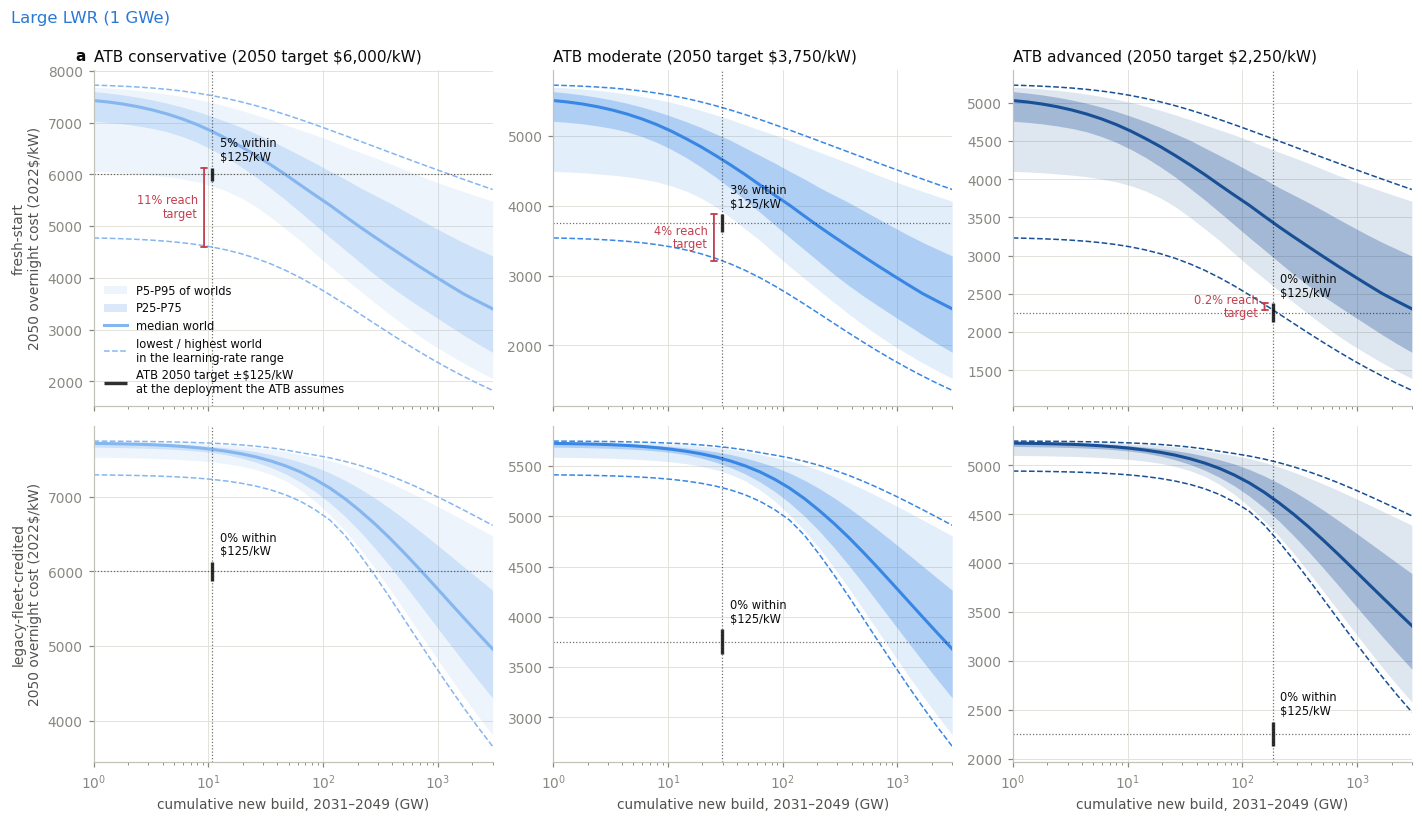

saved -> figures\atb_cost_deployment_plane_smr.png


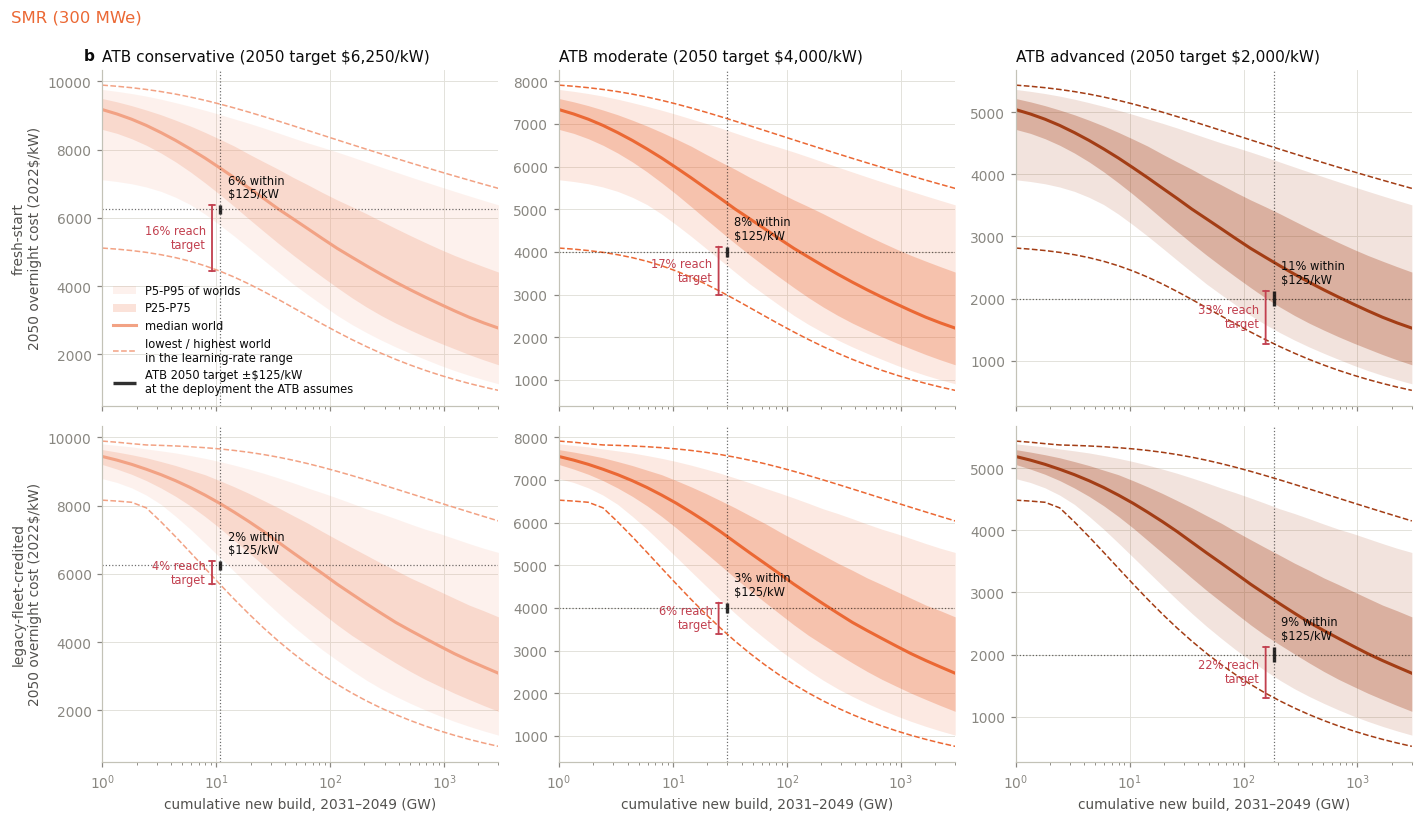

In [18]:
# F8 (Fig 1a/b, augmented 08-28) - the 2050 cost-deployment plane: the 2050 OCC each amount of
# cumulative building can buy, across the support-restricted grid worlds, with the ATB
# (paired deployment, 2050 cost) point overlaid. One figure per technology; rows = the
# experience-base strata (matching F3/F6); the quantile fan is over all grid worlds in the
# stratum with LR restricted to the MC sampled support (uniform grid weights over
# LR x s x u3 x m x rho, the Part-2 grid — no dial held fixed). The shape quantiles are
# computed once per stratum and scaled by each scenario's pinned anchor (quantiles commute
# with the positive per-scenario BOAK scaling).
# 08-28 (Ethan): Fig 1 = these two figures STACKED (a = large over b = smr); the endpoint
# maps (F9) leave the composition. Per panel: dashed P0/P100 envelope (lowest and highest
# supported world at each deployment) plus two reads at the paired deployment (second
# 08-28 spec, amended 08-29): a black bar spanning the target +-TOL_END band labeled
# with the stratum share of supported worlds inside the band (two-sided), and a red
# dimension bracket from the envelope floor to target + TOL_END labeled with the
# ONE-SIDED criterion share (OCC(2050) <= target + $125) - the S1 share itself, so
# panel and prose cannot drift; the bracket is omitted where that share is zero (the
# large legacy-fleet rows). The strictly-below read is retired (08-29). Both shares
# are SHAPES-based (the endpoint_feasible_share.csv population).
# 08-29 (Ethan): row labels de-jargonned - the internal stratum names (tiny-base /
# full-stock) stay out of paper-facing pixels; the descriptive labels match the
# Fig 1 caption (fresh-start / legacy-fleet-credited).
# 09-03 (Ethan, coauthor review): the remaining labels read in plain words - "occ",
# "supported world", "paired deployment", "reach" and the x label; no numeric change.
D_PLANE_GW = np.logspace(0.0, np.log10(3000.0), 28)          # 1 -> 3,000 GW by 2050

for tech in TECH:
    sup2 = (LR2 >= TECH[tech]["lr_lo"]) & (LR2 <= TECH[tech]["lr_hi"])
    sup1 = (P["lr"] >= TECH[tech]["lr_lo"]) & (P["lr"] <= TECH[tech]["lr_hi"])
    fig, axes = plt.subplots(2, 3, figsize=(13, 7.2), sharex=True)
    for r, conv in enumerate(CONV_GRID):
        combos = [(rho, m) for (rho, cv, m) in DISC_COMBOS if cv == conv]
        lr = np.concatenate([LR2[sup2]] * len(combos))
        s = np.concatenate([S2[sup2]] * len(combos))
        u = np.concatenate([U2[sup2]] * len(combos))
        m = np.concatenate([np.full(int(sup2.sum()), mm) for _, mm in combos])
        rho = np.concatenate([np.full(int(sup2.sum()), rr) for rr, _ in combos])
        q = np.empty((len(D_PLANE_GW), 5))
        env = np.empty((len(D_PLANE_GW), 2))     # P0/P100: lowest/highest supported world
        for k, d in enumerate(D_PLANE_GW):
            sh = shape_2050(tech, lr, s, u, m, conv, rho, d / TECH[tech]["unit_gw"])
            q[k] = np.quantile(sh, [0.05, 0.25, 0.50, 0.75, 0.95])
            env[k] = sh.min(), sh.max()
        for c, scen in enumerate(SCEN_ORDER):
            ax = axes[r, c]
            occ_q = q * BOAK_PIN[tech][scen]
            occ_env = env * BOAK_PIN[tech][scen]
            col = SCEN_COLOR[tech][scen]
            ax.fill_between(D_PLANE_GW, occ_q[:, 0], occ_q[:, 4], color=col, alpha=0.14,
                            lw=0, label="P5-P95 of worlds")
            ax.fill_between(D_PLANE_GW, occ_q[:, 1], occ_q[:, 3], color=col, alpha=0.30,
                            lw=0, label="P25-P75")
            ax.plot(D_PLANE_GW, occ_q[:, 2], color=col, lw=2, label="median world")
            ax.plot(D_PLANE_GW, occ_env[:, 0], color=col, lw=1.0, ls="--",
                    label="lowest / highest world\nin the learning-rate range")
            ax.plot(D_PLANE_GW, occ_env[:, 1], color=col, lw=1.0, ls="--")
            t50, d_aj = TARGET[tech][scen][-1], AJ_GW_ENT50[scen]   # thru-2049 scoring basis
            ax.axhline(t50, color=INK, lw=0.8, ls=":", alpha=0.6)
            ax.axvline(d_aj, color=INK, lw=0.8, ls=":", alpha=0.6)
            # 08-29 (Ethan): the target dot is removed - the +-$125 bar below IS the
            # target marker (it sits exactly at the paired deployment and target).
            # Panel reads at the paired deployment (third spec, 08-29, Ethan): each label
            # reads off the geometry it annotates. Populations identical to
            # endpoint_feasible_share.csv (SHAPES-based, support-restricted stratum); the
            # red bracket carries the paper's ONE-SIDED criterion share directly.
            pred50 = BOAK_PIN[tech][scen] * SHAPES[(tech, scen)][:, -1].astype(np.float64)
            strat = sup1 & (P["conv_full"] == conv)
            share_band = float((np.abs(pred50[strat] - t50) <= TOL_END).mean())
            share_feas = float((pred50[strat] <= t50 + TOL_END).mean())
            # Envelope floor exactly at the paired deployment (not interpolated).
            sh_aj = shape_2050(tech, lr, s, u, m, conv, rho, d_aj / TECH[tech]["unit_gw"])
            floor_aj = float(sh_aj.min()) * BOAK_PIN[tech][scen]
            # Black bar: the +-TOL band around the target; label = share inside the band.
            ax.plot([d_aj, d_aj], [t50 - TOL_END, t50 + TOL_END], color=INK, lw=2.2, alpha=0.85,
                    solid_capstyle="butt", zorder=4,
                    label="ATB 2050 target ±$125/kW\nat the deployment the ATB assumes")
            ax.annotate(f"{100*share_band:.0f}% within\n$125/kW", (d_aj, t50 + TOL_END),
                        xytext=(5, 3), textcoords="offset points", fontsize=7.5,
                        color=INK, va="bottom")
            # Red dimension bracket (left of the bar): envelope floor -> the upper
            # tolerance bound (target + $125); label = the one-sided criterion share
            # (worlds at or below the bound). Omitted where that share is zero
            # (08-29 spec - the large legacy-fleet rows). Sub-1% shares keep one
            # decimal so the large-advanced 0.2% stays visible.
            if share_feas > 0:
                x_dim = d_aj * 0.85
                bound = t50 + TOL_END
                lo_d, hi_d = min(bound, floor_aj), max(bound, floor_aj)
                ax.annotate("", (x_dim, hi_d), xytext=(x_dim, lo_d),
                            arrowprops=dict(arrowstyle="|-|,widthA=0.22,widthB=0.22",
                                            color=ps.ACCENT["red"], lw=1.2,
                                            shrinkA=0, shrinkB=0))
                lbl = (f"{100*share_feas:.1f}%" if share_feas < 0.01
                       else f"{100*share_feas:.0f}%")
                ax.annotate(lbl + " reach\ntarget", (x_dim, 0.5*(lo_d + hi_d)),
                            xytext=(-4, 0), textcoords="offset points", fontsize=7.5,
                            color=ps.ACCENT["red"], ha="right", va="center")
            ax.set_xscale("log")
            ax.set_xlim(1.0, 3000.0)
            if r == 0:
                ax.set_title(f"ATB {scen} (2050 target ${t50:,.0f}/kW)", fontsize=10)
            if c == 0:
                ax.set_ylabel(("fresh-start" if conv == 0 else "legacy-fleet-credited")
                              + "\n2050 overnight cost (2022$/kW)")
            if r == 1:
                ax.set_xlabel("cumulative new build, 2031–2049 (GW)")
    # Paper Fig 1 letters baked at source (house rule): "a" (large) / "b" (smr); the
    # composed Fig 1 stacks a over b since 08-28 (the F9 maps left the composition).
    ps.panel_letter(axes[0, 0], "a" if tech == "large" else "b")
    axes[0, 0].legend(fontsize=7.5, loc="lower left")
    fig.tight_layout()
    fig.suptitle(TECH_LABEL[tech], color=TECH_COLOR[tech], x=0.01, ha="left", y=1.03)
    ps.savefig(fig, FIGURES / f"atb_cost_deployment_plane_{tech}.png")
    plt.show()

**F9 (diagnostic since 08-28; formerly Fig 1c/d) — endpoint feasibility maps, one-sided** (`atb_endpoint_feasible_maps_{tech}.png`; panel letters removed 08-28 when the maps left the composed Fig 1). The shortfall of the 2050 cost against each ATB target — min over (u, m, ρ) of max(OCC(2050) − target, 0) at the paired deployment (the AJ annual path run through the
full engine, which applies the one-year lag itself) — over learning rate × spillover, tiny-base vs full-stock rows. The contour bounds the worlds that reach the target within \$125/kW (08-29 criterion:
one rounding half-step of the ATB's nearest-\$250 reporting); feasible = at or below the target plus tolerance (one-sided, ruling 08-24 — overshoot is success, not misfit). The printed table restates the feasible shares on this basis (with the two-sided and Part-1 milestone shares alongside) and is exported as `endpoint_feasible_share.csv`.

endpoint feasible shares, ONE-SIDED (reaches the 2050 cost: OCC(2050) <= target + $125/kW at the paired deployment; comparison columns: two-sided endpoint band, Part-1 milestone criterion) -> exports/atb/endpoint_feasible_share.csv
                    share_grid  share_support  share_support_tiny  share_support_full  share_support_twosided  share_support_milestone
tech  scenario                                                                                                                        
large conservative      0.2784         0.0570              0.1140              0.0000                  0.0247                   0.0000
      moderate          0.2754         0.0189              0.0377              0.0000                  0.0149                   0.0174
      advanced          0.2769         0.0011              0.0021              0.0000                  0.0011                   0.0045
smr   conservative      0.4559         0.1003              0.1627              0.0379        

saved -> figures\atb_endpoint_feasible_maps_large.png


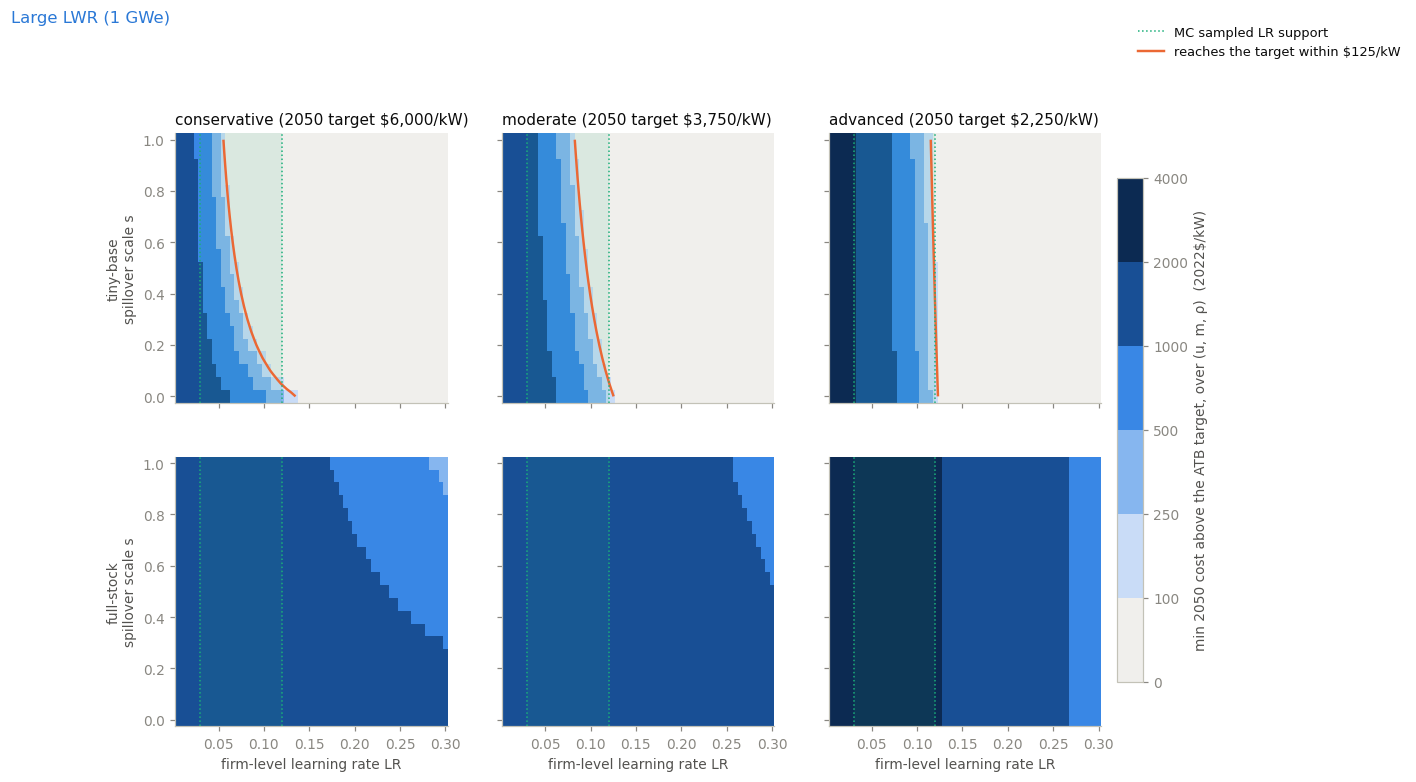

saved -> figures\atb_endpoint_feasible_maps_smr.png


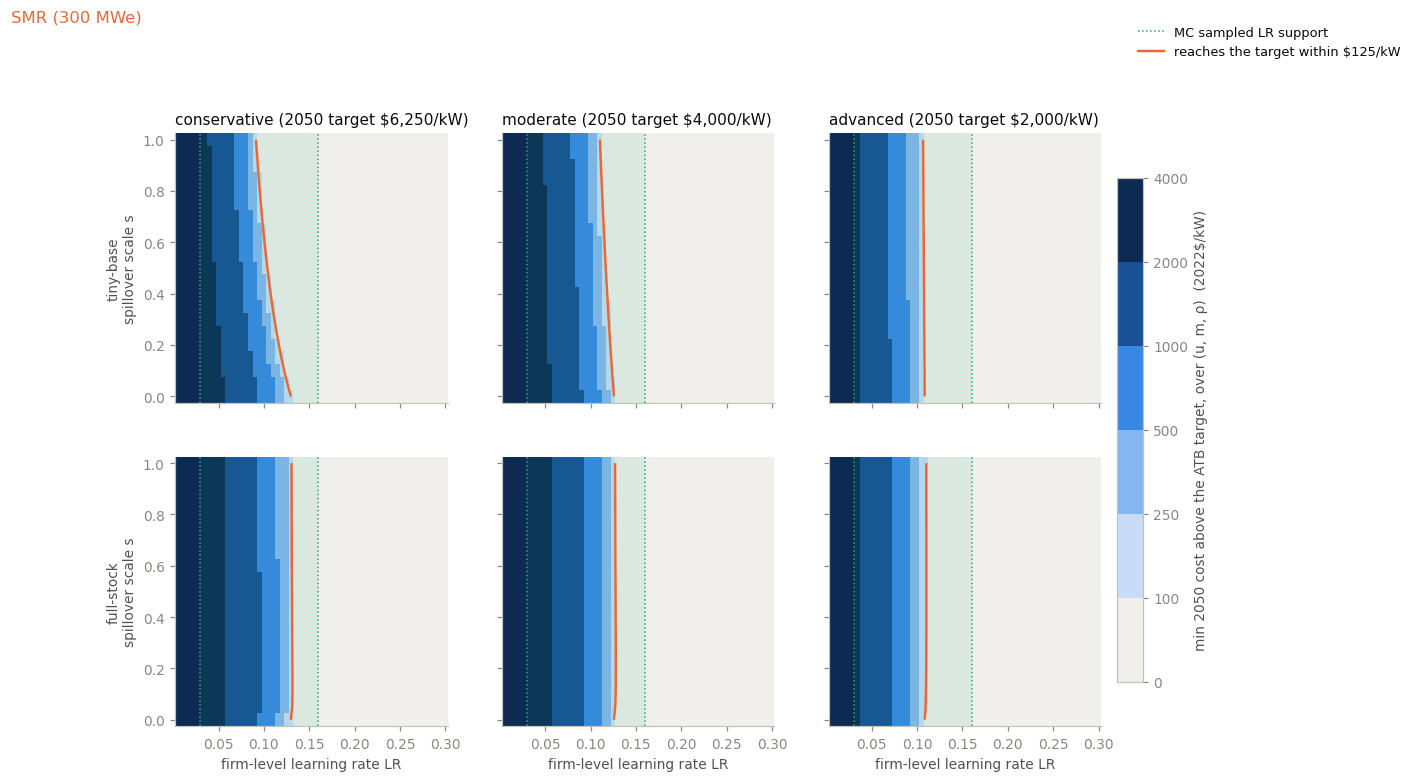

In [19]:
# F9 (diagnostic since 08-28; was Fig 1c/d 08-24 to 08-28) - endpoint feasibility, ONE-SIDED: a world is
# feasible when it REACHES the ATB 2050 cost at the paired deployment,
# OCC(2050) <= target + TOL_END ($125 since 08-29: one rounding half-step of the
# ATB's nearest-$250 reporting). Ruling 08-24: the section asks whether the cost is
# reachable, not matchable - the earlier two-sided band counted fast-learning worlds as
# infeasible by overshoot, which inverted the apparent LR ordering across scenarios.
# GAP50 = max(OCC(2050) - target, 0) is the shortfall; the two-sided misfit is kept as a
# comparison column in the exported table.
GAP50, MIS50 = {}, {}
for tech in TECH:
    for scen in SCEN_ORDER:
        pred50 = BOAK_PIN[tech][scen] * SHAPES[(tech, scen)][:, -1].astype(np.float64)
        GAP50[(tech, scen)] = np.maximum(pred50 - TARGET[tech][scen][-1], 0.0)
        MIS50[(tech, scen)] = np.abs(pred50 - TARGET[tech][scen][-1])

_rows = []
for (tech, scen), gap in GAP50.items():
    sup = (P["lr"] >= TECH[tech]["lr_lo"]) & (P["lr"] <= TECH[tech]["lr_hi"])
    tiny, full = P["conv_full"] == 0, P["conv_full"] == 1
    feas = gap <= TOL_END
    _rows.append({
        "tech": tech, "scenario": scen,
        "share_grid": round(float(feas.mean()), 4),
        "share_support": round(float(feas[sup].mean()), 4),
        "share_support_tiny": round(float(feas[sup & tiny].mean()), 4),
        "share_support_full": round(float(feas[sup & full].mean()), 4),
        "share_support_twosided": round(float((MIS50[(tech, scen)] <= TOL_END)[sup].mean()), 4),
        "share_support_milestone": round(float((FITS[(tech, scen)]["mis"] <= TOL)[sup].mean()), 4),
    })
end_share = pd.DataFrame(_rows).set_index(["tech", "scenario"])
end_share.to_csv(ATB_OUT / "endpoint_feasible_share.csv")
print("endpoint feasible shares, ONE-SIDED (reaches the 2050 cost: OCC(2050) <= target + "
      "$125/kW at the paired deployment; comparison columns: two-sided endpoint band, "
      "Part-1 milestone criterion) -> exports/atb/endpoint_feasible_share.csv")
print(end_share.to_string())
print("\n(min LR that reaches the 2050 cost at the paired deployment: T5, "
      "exports/atb/min_lr_at_aj_deployment.csv - already one-sided by construction)")

_lev50 = [0, 100, 250, 500, 1000, 2000, 4000]
_norm50 = BoundaryNorm(_lev50, CMAP_SEQ.N)
for tech in TECH:
    fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharex=True, sharey=True)
    for r, conv_name, conv_val in [(0, "tiny-base", 0), (1, "full-stock", 1)]:
        for c, scen in enumerate(SCEN_ORDER):
            ax = axes[r, c]
            g = GAP50[(tech, scen)].reshape(GRID_SHAPE)              # (rho,conv,m,lr,s,u)
            zmin = g[:, conv_val].min(axis=(0, 1, 4))                # (lr, s)
            pc = ax.pcolormesh(LR_GRID, S21, zmin.T, cmap=CMAP_SEQ, norm=_norm50,
                               shading="nearest")
            ax.grid(False)                                           # house heatmap rule
            if (zmin <= TOL_END).any() and (zmin > TOL_END).any():
                ax.contour(LR_GRID, S21, zmin.T, levels=[TOL_END], colors=[C_SMR], linewidths=1.6)
            ax.axvspan(TECH[tech]["lr_lo"], TECH[tech]["lr_hi"], color=C_TINY, alpha=0.10, lw=0)
            for x in (TECH[tech]["lr_lo"], TECH[tech]["lr_hi"]):
                ax.axvline(x, color=C_TINY, lw=1.0, ls=":")
            if r == 0:
                ax.set_title(f"{scen} (2050 target ${TARGET[tech][scen][-1]:,.0f}/kW)",
                             fontsize=10)
            if c == 0:
                ax.set_ylabel(f"{conv_name}\nspillover scale s")
            if r == 1:
                ax.set_xlabel("firm-level learning rate LR")
    # 08-28: these maps left the composed Fig 1 (panel letters removed); the CSV
    # export above stays load-bearing for the S1 prose shares and the F8 labels.
    handles = [Line2D([], [], color=C_TINY, lw=1.0, ls=":", label="MC sampled LR support"),
               Line2D([], [], color=C_SMR, lw=1.6,
                      label=f"reaches the target within ${TOL_END:.0f}/kW")]
    fig.legend(handles=handles, loc="upper right", fontsize=8.5, bbox_to_anchor=(0.99, 1.035))
    cb = fig.colorbar(pc, ax=axes, shrink=0.85, pad=0.015)
    cb.set_label("min 2050 cost above the ATB target, over (u, m, ρ)  (2022$/kW)")
    fig.suptitle(TECH_LABEL[tech], color=TECH_COLOR[tech], x=0.01, ha="left", y=1.04)
    ps.savefig(fig, FIGURES / f"atb_endpoint_feasible_maps_{tech}.png")
    plt.show()

In [20]:
# T5-his + endpoint-shares-his - dual-convention sensitivity (08-28, memo companion).
# Identical computations to T5 (atb-20-a21_solve_d) and the F9 share export, with ONLY the
# anchor attachment moved from our per-vendor 2OAK (own0 = 2 units/firm) to the attachment
# Abou-Jaoude's published tables apply: SMR first 1 GW = 3.333 industry units = 0.833/firm
# (companion QA4); large industry unit 2 = 0.5/firm (companion QA4b; eq. (10) "BOAK = 2OAK"
# with N counted industry-wide). own0 is per-firm in the engine, so his attachment is
# carried as a per-firm value at every m (it was derived at his m = 4). Lag, through-2049
# scoring basis, and all other dials unchanged - the columns isolate the convention.
OWN0_HIS = {"smr": (1.0/0.3)/4.0, "large": 2.0/4.0}

def shape_2050_at_own0(own0_val, tech, *args):
    """shape_2050 with the global anchor attachment temporarily overridden."""
    global N_BOAK_UNITS
    _saved = N_BOAK_UNITS
    N_BOAK_UNITS = float(own0_val)
    try:
        return shape_2050(tech, *args)
    finally:
        N_BOAK_UNITS = _saved

# Guard: the override round-trips (later cells keep the production anchor).
_probe = shape_2050("smr", 0.1, 0.5, 0.5, 6.0, 0.0, 0.0, 100.0)
_ = shape_2050_at_own0(OWN0_HIS["smr"], "smr", 0.1, 0.5, 0.5, 6.0, 0.0, 0.0, 100.0)
assert N_BOAK_UNITS == 2.0 and np.allclose(
    shape_2050("smr", 0.1, 0.5, 0.5, 6.0, 0.0, 0.0, 100.0), _probe)

# (1) T5 under his attachment - same loops, evaluator swapped.
_rows = []
for tech in TECH:
    for scen in SCEN_ORDER:
        ratio = TARGET[tech][scen][-1] / BOAK_PIN[tech][scen]
        n50 = AJ_GW_ENT50[scen] / TECH[tech]["unit_gw"]
        for conv in (0.0, 1.0):
            row = {"tech": tech, "scenario": scen, "base": "full" if conv else "tiny"}
            for s_val in (0.0, 0.5, 1.0):
                sh = shape_2050_at_own0(OWN0_HIS[tech], tech,
                                        LR_GRID, s_val, 0.5, 6.0, conv, 0.0, n50)
                ok = np.flatnonzero(sh <= ratio)
                row[f"min LR @ s={s_val}"] = LR_GRID[ok[0]] if ok.size else np.nan
            _rows.append(row)
min_lr_his = pd.DataFrame(_rows).set_index(["tech", "scenario", "base"])
min_lr_his.to_csv(ATB_OUT / "min_lr_at_aj_deployment_his_anchor.csv")
print("T5-his - minimum firm-level LR at the paired deployment under HIS attachment "
      "(all else as T5) -> exports/atb/min_lr_at_aj_deployment_his_anchor.csv")
_cmp = min_lr.join(min_lr_his, lsuffix=" [ours]", rsuffix=" [his]")
print(_cmp.to_string())
_delta = (min_lr - min_lr_his).stack()
print(f"\nours-minus-his spread over finite cells: "
      f"{_delta.min():.3f} to {_delta.max():.3f} LR points "
      f"(median {_delta.median():.3f})")

# (2) One-sided endpoint feasible shares under his attachment, on the same flat Part-1
# population; closed-form evaluation (QA-5a: closed form == engine 2050 column), with a
# baseline cross-check against the SHAPES-based F9 export before trusting the new column.
_rows = []
for tech in TECH:
    sup = (P["lr"] >= TECH[tech]["lr_lo"]) & (P["lr"] <= TECH[tech]["lr_hi"])
    tiny, full = P["conv_full"] == 0, P["conv_full"] == 1
    for scen in SCEN_ORDER:
        n50 = AJ_GW_ENT50[scen] / TECH[tech]["unit_gw"]
        t50 = TARGET[tech][scen][-1]
        args = (P["lr"], P["s"], P["u"], P["n_vendors"], P["conv_full"], P["ces_rho"], n50)
        base50 = BOAK_PIN[tech][scen] * shape_2050(tech, *args)
        chk = float((np.maximum(base50 - t50, 0.0) <= TOL_END)[sup].mean())
        ref = float((GAP50[(tech, scen)] <= TOL_END)[sup].mean())
        assert abs(chk - ref) < 2e-3, (tech, scen, chk, ref)   # float32 SHAPES vs float64
        his50 = BOAK_PIN[tech][scen] * shape_2050_at_own0(OWN0_HIS[tech], tech, *args)
        feas = np.maximum(his50 - t50, 0.0) <= TOL_END
        _rows.append({"tech": tech, "scenario": scen,
                      "share_support_his": round(float(feas[sup].mean()), 4),
                      "share_support_tiny_his": round(float(feas[sup & tiny].mean()), 4),
                      "share_support_full_his": round(float(feas[sup & full].mean()), 4),
                      "share_support_ours": round(ref, 4)})
end_share_his = pd.DataFrame(_rows).set_index(["tech", "scenario"])
end_share_his.to_csv(ATB_OUT / "endpoint_feasible_share_his_anchor.csv")
print("\nendpoint feasible shares (one-sided, support-restricted) under HIS attachment "
      "-> exports/atb/endpoint_feasible_share_his_anchor.csv")
print(end_share_his.to_string())

T5-his - minimum firm-level LR at the paired deployment under HIS attachment (all else as T5) -> exports/atb/min_lr_at_aj_deployment_his_anchor.csv
                         min LR @ s=0.0 [ours]  min LR @ s=0.5 [ours]  min LR @ s=1.0 [ours]  min LR @ s=0.0 [his]  min LR @ s=0.5 [his]  min LR @ s=1.0 [his]
tech  scenario     base                                                                                                                                       
large conservative tiny                  0.195                  0.145                  0.130                 0.085                 0.075                 0.070
                   full                    NaN                    NaN                    NaN                   NaN                   NaN                   NaN
      moderate     tiny                  0.170                  0.150                  0.145                 0.090                 0.085                 0.085
                   full                    NaN           


endpoint feasible shares (one-sided, support-restricted) under HIS attachment -> exports/atb/endpoint_feasible_share_his_anchor.csv
                    share_support_his  share_support_tiny_his  share_support_full_his  share_support_ours
tech  scenario                                                                                           
large conservative             0.3053                  0.6106                  0.0000              0.0570
      moderate                 0.2407                  0.4814                  0.0000              0.0189
      advanced                 0.1471                  0.2942                  0.0000              0.0011
smr   conservative             0.3656                  0.4771                  0.2541              0.1003
      moderate                 0.3364                  0.4244                  0.2484              0.1137
      advanced                 0.4059                  0.4818                  0.3301              0.2744


**F10 (candidate) — endpoint-only dial marginals** (`atb_endpoint_dial_marginals_{tech}.png`). The F4 marginal profiles re-scored on the 2050 endpoint: for each dial value, the share of endpoint-feasible worlds among grid worlds holding that value — which dials the 2050 target alone pins down.

saved -> figures\atb_endpoint_dial_marginals_large.png


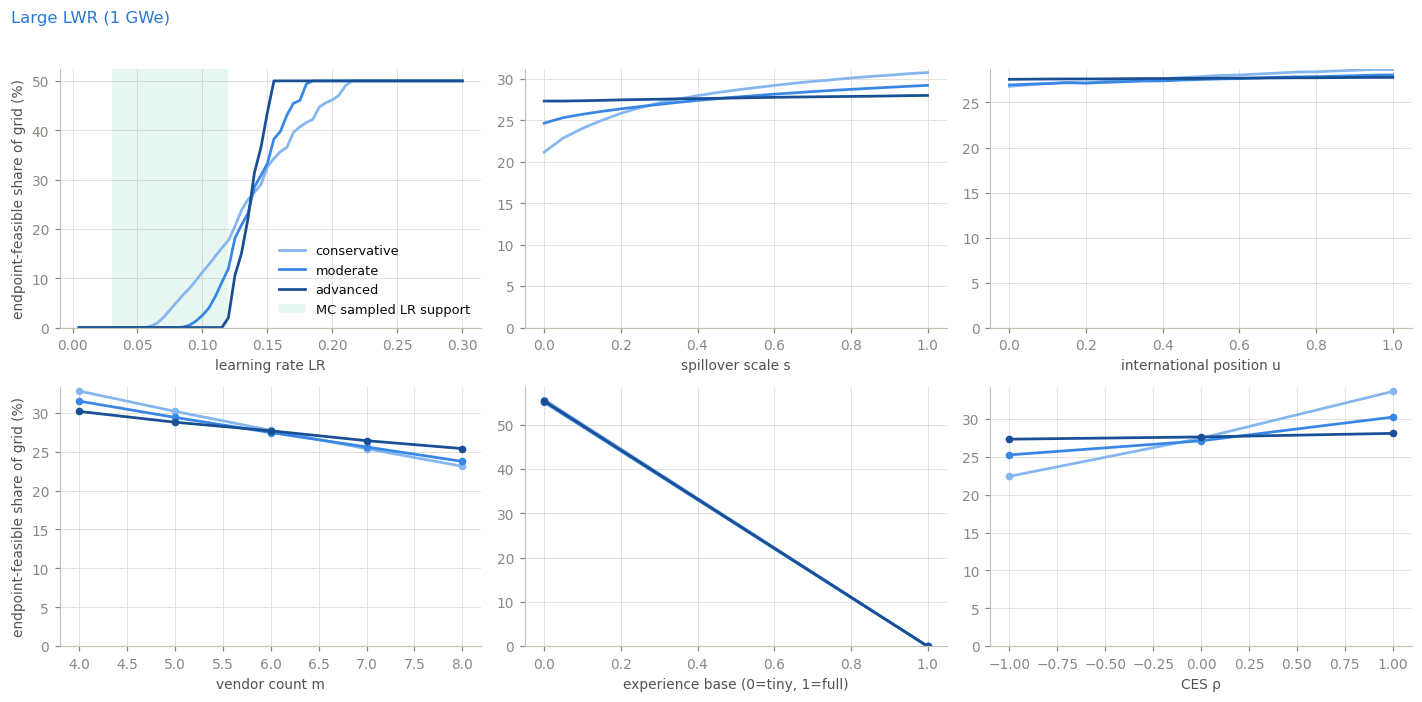

saved -> figures\atb_endpoint_dial_marginals_smr.png


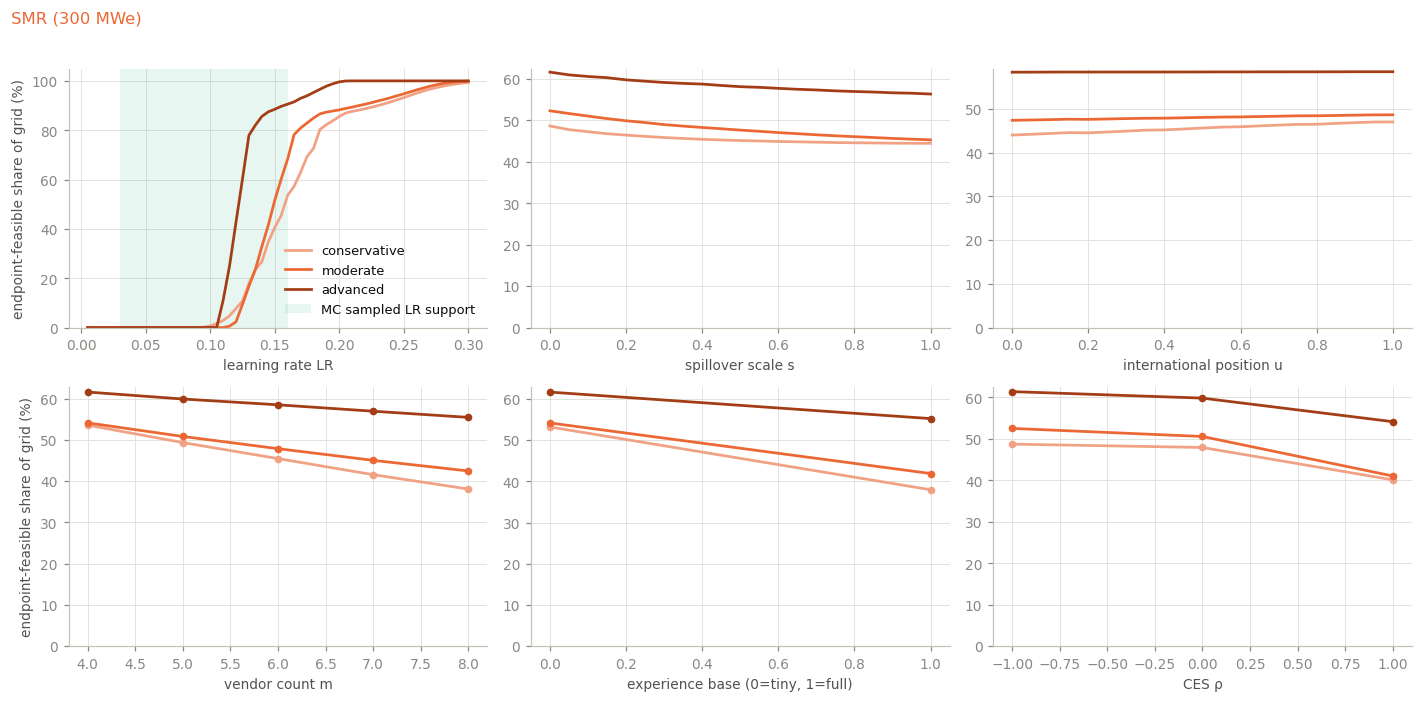

In [21]:
# F10 (SI candidate) - the F4 dial marginals re-scored on the 2050 endpoint, one-sided
# basis (08-24; $125 criterion since 08-29: feasible = GAP50 <= TOL_END): for each dial value, the
# share of endpoint-feasible worlds among grid worlds with that value. Interpretation
# guard: each scenario is scored at its own paired deployment (12/33/199 GW), so the LR
# orderings reflect the ATB's pairing structure, not the targets alone.
for tech in TECH:
    fig, axes = plt.subplots(2, 3, figsize=(13, 6.2))
    for ax, dial in zip(axes.ravel(), ["lr", "s", "u", "n_vendors", "conv_full", "ces_rho"]):
        ax_i = _AXIS[dial]
        other = tuple(i for i in range(6) if i != ax_i)
        for scen in SCEN_ORDER:
            feas = (GAP50[(tech, scen)] <= TOL_END).reshape(GRID_SHAPE)
            frac = 100.0 * feas.mean(axis=other)
            ax.plot(_VALS[dial], frac, color=SCEN_COLOR[tech][scen], lw=1.8,
                    marker="o" if dial in ("ces_rho", "conv_full", "n_vendors") else None,
                    ms=4, label=scen)
        if dial == "lr":
            ax.axvspan(TECH[tech]["lr_lo"], TECH[tech]["lr_hi"], color=C_TINY, alpha=0.10, lw=0,
                       label="MC sampled LR support")
        ax.set_xlabel(_XLAB[dial])
        ax.set_ylim(bottom=0)
    axes[0, 0].set_ylabel("endpoint-feasible share of grid (%)")
    axes[1, 0].set_ylabel("endpoint-feasible share of grid (%)")
    axes[0, 0].legend(fontsize=8.5)
    fig.suptitle(TECH_LABEL[tech], color=TECH_COLOR[tech], x=0.01, ha="left", y=1.02)
    fig.tight_layout()
    ps.savefig(fig, FIGURES / f"atb_endpoint_dial_marginals_{tech}.png")
    plt.show()

## A7 — Synthesis: the RQ2 verdict table

One row per technology × scenario, combining both parts:

- **Part-1 verdict** — is the full ATB trajectory reproducible at the paired deployment
  (a) inside the MC's sampled parameter support, (b) only outside it (learning rates the MC
  deliberately does not sample), or (c) nowhere on the extended grid?
- **Part-2 read** — the deployment a *central in-support world* would need to reach the 2050
  cost, next to what Abou-Jaoude assumed.

**What the run shows** (2026-08-06 export; the table below and T2–T5 carry the exact numbers):

- **All three ATB SMR trajectories are reproducible inside the MC prior — but only in its upper
  learning tail.** Best fits sit at LR 12–13% (mostly with strong spillover), against
  Abou-Jaoude's own 9.5%: the paper's 2030-anchor convention folds pre-2030 experience into the
  anchor and re-anchors at the per-vendor 2OAK point, which costs roughly 2–3 points of firm-level
  LR relative to the source's accounting (QA-3 (ii) shows the same setting overshooting the 2050
  targets by $360–860/kW). Grid-best fits: moderate/advanced at LR 12.5–13% (in-support);
  conservative's grid best sits at 17.5%, outside the 16% cap, with in-support fits only near the
  tolerance edge (min in-support misfit $220/kW). In-support feasible shares are thin —
  0.03-0.86% of the support-restricted grid at the $250/kW tolerance.
- **The ATB large-nuclear trajectories are harder to rationalize.** Moderate and advanced are
  reachable in-support only in the upper-spillover corner (grid-best fits at LR 13–13.5%, just
  past the 12% cap; in-support shares 0.45–1.74%). Conservative — a 23% cost decline on just
  12 GW of builds — clears the tolerance nowhere in the support (min in-support misfit
  ≈ $277/kW) and needs LR ≈ 18% without spillover help.
- **Every large trajectory presumes fresh-start learning.** Under the full-stock convention
  (crediting the ~135-unit US LWR fleet), no learning rate up to 30% bends the curve enough (T5:
  all NaN) — the ATB large-nuclear declines are only consistent with tiny-base (FOAK-like)
  experience accounting, the same convention question flagged for the paper's methods section.
- **Part 2 prices the gap in deployment units:** at Abou-Jaoude's own parameter point the engine
  wants roughly **2–3.4× the paired deployments** (SMR advanced: 484 GW vs the assumed 200; large
  advanced: 677 GW), and at MC-central in-support worlds ≈3–18×. Equivalently (T5), the paired
  deployments suffice only at LR ≥ 12.5% (SMR advanced) up to ≥ 18% (large conservative, s=0).

Read with the standing caveats: the engine models a **standardized-program regime** (the
France/US negative-learning record lies outside its support by construction — companion QA5),
so "reproducible" always means *reproducible if programs execute like successful historical
programs*. And this comparison is NREL-benchmarking-NREL: the ATB numbers and the engine share
Abou-Jaoude ancestry, which is exactly why reproducing them pins down the implied assumptions
rather than validating them.

In [22]:
# The synthesis table (T6): Part-1 feasibility verdict + Part-2 required deployment, per fit.
_rows = []
for tech in TECH:
    lr_mid = 0.5*(TECH[tech]["lr_lo"] + TECH[tech]["lr_hi"])
    for scen in SCEN_ORDER:
        f = FITS[(tech, scen)]
        sup = (P["lr"] >= TECH[tech]["lr_lo"]) & (P["lr"] <= TECH[tech]["lr_hi"])
        feas_any = f["mis"].min() <= TOL
        feas_sup = f["mis"][sup].min() <= TOL
        verdict = ("(a) inside MC support" if feas_sup else
                   "(b) outside support only" if feas_any else
                   "(c) not on the grid")
        ratio = TARGET[tech][scen][-1] / BOAK_PIN[tech][scen]
        d_ctr = required_gw(tech, ratio, lr_mid, 0.5, 0.5, 6.0, 0.0, 0.0).item()
        _rows.append({
            "tech": tech, "scenario": scen, "verdict": verdict,
            "min_misfit_grid_$kW": round(float(f["mis"].min()), 1),
            "min_misfit_support_$kW": round(float(f["mis"][sup].min()), 1),
            f"share_support_<=${TOL:.0f}": round(float((f['mis'][sup] <= TOL).mean()), 4),
            "AJ_deployment_GW": AJ_GW_POST[scen],
            "AJ_completed_2049_GW": round(AJ_GW_ENT50[scen], 1),
            "required_GW_central_world": (round(d_ctr, 1) if np.isfinite(d_ctr) else np.inf),
        })
synthesis = pd.DataFrame(_rows).set_index(["tech", "scenario"])
synthesis.to_csv(ATB_OUT / "synthesis.csv")
print("T6 - the RQ2 synthesis (central world = LR mid-support, tiny base, s=0.5, u=0.5, m=6, "
      "rho=0) -> exports/atb/synthesis.csv")
print(synthesis.to_string())

T6 - the RQ2 synthesis (central world = LR mid-support, tiny base, s=0.5, u=0.5, m=6, rho=0) -> exports/atb/synthesis.csv
                                     verdict  min_misfit_grid_$kW  min_misfit_support_$kW  share_support_<=$250  AJ_deployment_GW  AJ_completed_2049_GW  required_GW_central_world
tech  scenario                                                                                                                                                                    
large conservative  (b) outside support only                231.9                   277.4                0.0000              12.0                  10.8                       47.8
      moderate         (a) inside MC support                 78.9                   100.9                0.0174              33.0                  29.6                      191.4
      advanced         (a) inside MC support                 38.2                    79.0                0.0045             199.0                 183.8           

## A8 — QA suite

House discipline: one check per cell, self-announcing PASS/FAIL, hard asserts. QA-0 (engine-port
parity against `mc_perdraw.npz`) ran up front in A2; QA-4 (anchor identity on every grid world)
ran inline as the shapes were built; QA-5a/b/c (closed-form 2050 evaluator, path invariance,
monotonicity) and QA-6 (bisection round-trip) ran inside Part 2. The remaining checks:

- **QA-1** — the CES engine at ρ→0 reproduces the σ=1 reference engine exactly, on designed
  worlds spanning the full extended LR grid;
- **QA-2** — at s=0, tiny base, ρ=0 the engine collapses to generalized eq. (12) analytically
  (the closed form Part 1's intuition leans on);
- **QA-3** — the published-source pin: Abou-Jaoude's SMR OCC tables are reproduced by his own
  eq. (12) at LR 9.5%, m=4 (verbatim companion QA4), and this notebook's Part-1 machinery finds
  the corresponding engine world feasible for the SMR fits.

In [23]:
# QA-1 - CES(rho -> 0) == the sigma = 1 reference engine, on designed worlds spanning the grid
_rng1 = rng_stream("atb/qa1")
_n1 = 300
_wq = make_worlds(_rng1.uniform(0.005, 0.30, _n1), _rng1.uniform(4000, 10000, _n1),
                  _rng1.uniform(0, 1, _n1), _rng1.uniform(0, 1, _n1),
                  _rng1.integers(4, 9, _n1).astype(float),
                  _rng1.integers(0, 2, _n1).astype(float), 0.0)
for tech in TECH:
    a = occ_paths_ces(_wq, tech, N_AJ[tech]["advanced"], ces_rho=0.0)
    b = occ_paths(_wq, tech, N_AJ[tech]["advanced"])
    assert np.allclose(a, b, rtol=1e-12), tech
print("QA-1 PASSED: occ_paths_ces(rho=0) == occ_paths exactly on 300 designed worlds "
      "spanning the extended LR grid (both techs, AJ advanced deployment)")

# QA-2 - eq.(12) identity: at s = 0, tiny base, the engine equals generalized eq. (12),
# per-vendor re-anchored (the companion's QA3, on this notebook's own deployment inputs)
_wq2 = make_worlds(_rng1.uniform(0.005, 0.30, 4), 1.0, _rng1.uniform(0, 1, 4), 0.0,
                   _rng1.integers(4, 9, 4).astype(float), 0.0, 0.0)
_nus2 = N_AJ["smr"]["advanced"]
_m2q = _wq2["n_vendors"].values[:, None]
_N_ind = _m2q*N_BOAK_UNITS + lag1(np.broadcast_to(_nus2, (4, T)))   # engine prices lagged stock
_lr2 = _wq2["lr_smr"].values[:, None]
_analytic = eq12_gen(_N_ind, _lr2, _m2q) / eq12_gen(_m2q*N_BOAK_UNITS, _lr2, _m2q)
assert np.allclose(occ_paths(_wq2, "smr", _nus2), _analytic, rtol=1e-12)
print("QA-2 PASSED: engine reduces exactly to generalized eq.(12) at s=0, tiny base "
      "(SMR, AJ advanced deployment)")

# QA-3 - the published-source pin, two halves.
# (i) VERBATIM companion QA4: Abou-Jaoude's own eq. (12) at LR 9.5%, m=4 reproduces his
#     published SMR OCC tables (= the ATB SMR trajectories) within report rounding.
def eq12_factor(N, LR):
    N = np.asarray(N, float)
    with np.errstate(divide="ignore", invalid="ignore"):
        return (1/(1-LR)) * (1-LR)**np.log2(N/4) * (1-LR/3)**np.log2(3*N/4)

_worst = 0.0
for s in SCEN_ORDER:
    N = np.array([_aj_qa4[s][y] for y in MILESTONES], float) / 0.3
    fref = eq12_factor(1.0/0.3, 0.095)
    mult = np.minimum(1.0, np.where(N > 0, eq12_factor(N, 0.095)/fref, 1.0))
    boak = {"conservative": 10000.0, "moderate": 8000.0, "advanced": 5500.0}[s]
    _worst = max(_worst, float(np.abs(boak*mult - TARGET["smr"][s]).max()))
assert _worst <= 500.0, _worst
print(f"QA-3 (i) PASSED: Abou-Jaoude eq.(12) @ LR 9.5%, m=4 reproduces the ATB SMR tables, "
      f"max error ${_worst:,.0f}/kW (report rounding)")

# (ii) The same setting evaluated through THIS engine, whose 2030-anchor convention discards
#      pre-2030 experience and re-anchors at the per-vendor 2OAK point - so it needs a somewhat
#      higher LR than Abou-Jaoude's own 9.5% to deliver the same curve. Report the gap, and
#      assert the substantive claim: every SMR trajectory has feasible worlds INSIDE the MC's
#      sampled LR support at the paired deployment.
for s in SCEN_ORDER:
    prec = BOAK_PIN["smr"][s] * shape_2050("smr", 0.095, 0.0, 0.5, 4.0, 0.0, 0.0,
                                           AJ_GW_ENT50[s]/0.3)   # thru-2049 scoring basis
    print(f"    engine @ AJ precedent world, {s:12s}: OCC(2050) = ${float(prec):,.0f}/kW "
          f"vs ATB ${TARGET['smr'][s][-1]:,.0f}/kW")
for s in SCEN_ORDER:
    sup = (P["lr"] >= TECH["smr"]["lr_lo"]) & (P["lr"] <= TECH["smr"]["lr_hi"])
    assert (FITS[("smr", s)]["mis"][sup] <= TOL).any(), s
print("QA-3 (ii) PASSED: every ATB SMR trajectory is reachable within the MC's sampled LR "
      "support at the paired AJ deployment (the anchor-convention LR premium stays in-support)")

QA-1 PASSED: occ_paths_ces(rho=0) == occ_paths exactly on 300 designed worlds spanning the extended LR grid (both techs, AJ advanced deployment)
QA-2 PASSED: engine reduces exactly to generalized eq.(12) at s=0, tiny base (SMR, AJ advanced deployment)
QA-3 (i) PASSED: Abou-Jaoude eq.(12) @ LR 9.5%, m=4 reproduces the ATB SMR tables, max error $500/kW (report rounding)
    engine @ AJ precedent world, conservative: OCC(2050) = $7,228/kW vs ATB $6,250/kW
    engine @ AJ precedent world, moderate    : OCC(2050) = $4,885/kW vs ATB $4,000/kW
    engine @ AJ precedent world, advanced    : OCC(2050) = $2,402/kW vs ATB $2,000/kW
QA-3 (ii) PASSED: every ATB SMR trajectory is reachable within the MC's sampled LR support at the paired AJ deployment (the anchor-convention LR premium stays in-support)


In [24]:
# Run metadata + integrity hashes of every file this notebook wrote (house S16 pattern).
import hashlib

def _crc(path):
    return f"{zlib.crc32(Path(path).read_bytes()):08x}"

_written = sorted([p for p in ATB_OUT.iterdir() if p.is_file() and p.name != "atb_metadata.json"]) \
    + sorted(FIGURES.glob("atb_*.png"))
_meta = {
    "notebook": "atb_parameter_space.ipynb",
    "purpose": "RQ2 inversion: parameter space consistent with the ATB 2024 nuclear cost "
               "trajectories at Abou-Jaoude deployments (part 1) and with the 2050 costs at "
               "free deployment (part 2)",
    "master_seed": MASTER_SEED,
    "engine": "verbatim port of mc_cost_trajectories.ipynb S1/S3/S5 (cross-firm intl "
              "routing, x_ls = x_sl pinned 0.15 - inert, no cross-tech program); "
              "QA-0 parity vs mc_perdraw.npz",
    "grid": {"lr": [float(LR_GRID[0]), float(LR_GRID[-1]), len(LR_GRID)],
             "s": len(S21), "u": len(U21), "m": [4, 8], "conv_full": [0, 1],
             "ces_rho": list(map(float, CES_RHO_GRID)),
             "worlds_per_fit": int(NW)},
    "tolerance_usd_per_kw": {"primary": TOL, "endpoint": TOL_END, "ladder": TOLS},
    "fit_milestones": MYEARS,
    "d_max_gw": D_MAX_GW,
    "occ_basis": "overnight capital cost, IDC-exclusive, $/kW in 2022 USD (ATB basis)",
    "inputs": {
        "atb_files": {f"{ATB_NAME[t]}_ATB_2024_{s}.csv":
                      _crc(PC_DIR / f"{ATB_NAME[t]}_ATB_2024_{s}.csv")
                      for t in TECH for s in SCEN_ORDER},
        "aj_deployment_csv": _crc(REPO_ROOT / "z-ethan" /
                                  "abou-jaoude nuclear deployment projections.csv"),
        "us_schedules_csv": _crc(REPO_ROOT / "inputs" / "nuclear_learning" / "US_SCHEDULES.csv"),
        "mc_perdraw_npz": _crc(EXPORTS / "mc_perdraw.npz"),
    },
    "written": {str(p.relative_to(NB_DIR)): _crc(p) for p in _written},
}
with open(ATB_OUT / "atb_metadata.json", "w", newline="\n") as f:
    json.dump(_meta, f, indent=2)
print(f"wrote exports/atb/atb_metadata.json ({len(_meta['written'])} files hashed)")

# Round-trip check: every export re-reads to what is in memory (spot: the targets table)
_back = pd.read_csv(ATB_OUT / "atb_targets.csv", header=[0, 1], index_col=0)
assert np.allclose(_back.to_numpy(float),
                   np.column_stack([TARGET[t][s] for t in TECH for s in SCEN_ORDER])), \
    "atb_targets.csv round-trip mismatch"
print("round-trip check PASSED: atb_targets.csv re-reads to the in-memory targets")

wrote exports/atb/atb_metadata.json (34 files hashed)
round-trip check PASSED: atb_targets.csv re-reads to the in-memory targets


---

**Provenance.** Engine: verbatim port of `mc_cost_trajectories.ipynb` S1/S3/S5 (QA-0 parity
against `exports/mc_perdraw.npz`). Targets: the fork's own ATB 2024 plant-characteristics files.
Deployments: `z-ethan/abou-jaoude nuclear deployment projections.csv`, pinned to the companion's
QA4 transcription of the published tables. Outputs: `exports/atb/` (tables, per-world misfit
arrays, metadata with integrity hashes) and `figures/atb_*.png`. This notebook draws nothing at
random except QA sample worlds, writes nothing into the ReEDS input tree, and requires no ReEDS
runs — RQ2 is complete when it runs green.